In [19]:
"""
Final Project
Author: Patrick Kobrick
Assignment: Final Project
Due Date: December 1st, 2025
Course: AST 5765/4762 - (Advanced) Astronomical Data Analysis
"""

'\nFinal Project\nAuthor: Patrick Kobrick\nAssignment: Final Project\nDue Date: December 1st, 2025\nCourse: AST 5765/4762 - (Advanced) Astronomical Data Analysis\n'

In [2]:
# Problem 1

In [3]:
# Problem 2

In [4]:
# Problem 3 (Imports)

import numpy as np
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import center_of_mass
from scipy.ndimage import uniform_filter1d
# from process_spitzer import process_spitzer_data  # Import your main function (WILL ADD LATER WHEN I PUT THE SUPPORT FUNCTION IN ITS OWN
# .PY FILE

In [5]:
# Problem 4

# ===================================================================
# PART 4: Data reading and processing function
# ===================================================================

import os
import numpy as np
from astropy.io import fits

def process_spitzer_data(start_set, num_sets, data_path=None):
    """
    Complete function to read and process Spitzer IRAC subarray data.
    
    (a) Read first data block to get information
    (b) Allocate 3D data cube and 2D frame-parameter array
    (c) Loop over images and populate arrays with data and timing
    
    Parameters:
    -----------
    start_set : int
        Starting subarray set number (e.g., 187)
    num_sets : int
        Number of sets to read
    data_path : str, optional
        Path to data directory. If None, looks for 'data' folder 
        in the current working directory.
    
    Returns:
    --------
    data_cube : ndarray
        3D array containing all image frames
    frame_params : ndarray
        Array with frame parameters (frame_num, mid_time, exptime, framtime)
    header : fits.Header
        Header from first file for reference
    """
    
    # If no path provided, use 'data' subdirectory in current working directory
    if data_path is None:
        # For Jupyter notebooks, use current working directory
        data_path = os.path.join(os.getcwd(), 'data')
    
    # Convert to absolute path and check if it exists
    data_path = os.path.abspath(data_path)
    
    if not os.path.exists(data_path):
        raise FileNotFoundError(
            f"Data directory not found: {data_path}\n"
            f"Current working directory: {os.getcwd()}\n"
            "Please ensure the 'data' folder exists in your working directory,\n"
            "or specify the correct path using the data_path parameter."
        )
    
    print(f"Using data directory: {data_path}")
    
    # (a) Read first data block
    print("=" * 60)
    print("PART 4(a): Reading first data block")
    print("=" * 60)
    
    first_file = f"SPITZER_I4_20674048_{start_set:04d}_0000_2_bcd.fits"
    first_path = os.path.join(data_path, first_file)
    
    print(f"Reading: {first_file}")
    
    with fits.open(first_path) as hdul:
        data = hdul[0].data
        header = hdul[0].header
        
        frames_per_set = data.shape[0]
        img_height = data.shape[1]
        img_width = data.shape[2]
        
        print(f"\nData cube dimensions in one file: {data.shape}")
        print(f"Number of frames per subarray set: {frames_per_set}")
        print(f"Image dimensions: {img_height} x {img_width} pixels")
        
        print(f"\nKey header information:")
        print(f"  EXPTIME: {header['EXPTIME']} seconds")
        print(f"  FRAMTIME: {header['FRAMTIME']} seconds")
        print(f"  DATE_OBS: {header['DATE_OBS']}")
        print(f"  MJD_OBS: {header['MJD_OBS']}")
    
    # (b) Allocate data structures
    print("\n" + "=" * 60)
    print("PART 4(b): Allocating data structures")
    print("=" * 60)
    
    total_frames = num_sets * frames_per_set
    
    print(f"\nNumber of sets to process: {num_sets}")
    print(f"Total number of frames: {total_frames}")
    
    data_cube = np.zeros((total_frames, img_height, img_width))
    print(f"\nAllocated 3D data cube")
    print(f"  Shape: {data_cube.shape}")
    
    num_params = 4  # frame_number, mid_time, exptime, framtime
    frame_params = np.zeros((total_frames, num_params))
    
    print(f"\nAllocated frame parameters array")
    print(f"  Shape: {frame_params.shape}")
    
    # (c) Loop over images and populate
    print("\n" + "=" * 60)
    print("PART 4(c): Reading and populating data")
    print("=" * 60)
    print(f"\nProcessing sets {start_set} to {start_set + num_sets - 1}")
    
    for i in range(num_sets):
        set_num = start_set + i
        filename = f"SPITZER_I4_20674048_{set_num:04d}_0000_2_bcd.fits"
        filepath = os.path.join(data_path, filename)
        
        # Print every 10th file
        if i % 10 == 0:
            print(f"\nReading: {filename}")
        
        # (c.i) Read the data and header
        with fits.open(filepath) as hdul:
            data = hdul[0].data
            header = hdul[0].header
            
            if i % 10 == 0:
                print(f"  DATE_OBS: {header['DATE_OBS']}")
            
            # (c.iii) Get timing information
            mjd_obs = header['MJD_OBS']
            exptime = header['EXPTIME']
            framtime = header['FRAMTIME']
            
            exptime_days = exptime / 86400.0
            framtime_days = framtime / 86400.0
            
            first_frame_midtime = mjd_obs + (exptime_days / 2.0)
            
            # (c.ii) Insert frames into data cube
            start_idx = i * frames_per_set
            end_idx = start_idx + frames_per_set
            
            data_cube[start_idx:end_idx, :, :] = data
            
            # (c.iii) Populate frame parameters
            for j in range(frames_per_set):
                frame_num = start_idx + j
                frame_midtime = first_frame_midtime + j * framtime_days
                
                frame_params[frame_num, 0] = frame_num
                frame_params[frame_num, 1] = frame_midtime
                frame_params[frame_num, 2] = exptime
                frame_params[frame_num, 3] = framtime
    
    print("\n" + "=" * 60)
    print("PART 4 Complete")
    print("=" * 60)
    
    return data_cube, frame_params, header

In [6]:
# Problem 5

# ===================================================================
# PART 5: Run and verify
# ===================================================================

def verify_data(data_cube, frame_params):
    """Run checks on the data."""
    
    print("\n" + "=" * 60)
    print("PART 5: Data verification")
    print("=" * 60)
    
    # Check for blank frames
    frame_means = np.mean(data_cube, axis=(1, 2))
    frame_maxs = np.max(data_cube, axis=(1, 2))
    
    zero_frames = np.where(frame_maxs == 0)[0]
    
    if len(zero_frames) > 0:
        print(f"WARNING: Found {len(zero_frames)} blank frames")
    else:
        print("✓ No blank frames detected")
    
    # Check last 10 frames
    print(f"\nLast 10 frames check:")
    for i in range(-10, 0):
        frame_idx = data_cube.shape[0] + i
        print(f"  Frame {frame_idx}: mean={frame_means[frame_idx]:.4f}, max={frame_maxs[frame_idx]:.4f}")
    
    # Plot a few sample frames
    print(f"\nPlotting sample frames...")
    
    total_frames = data_cube.shape[0]
    frames_to_plot = [0, total_frames // 2, total_frames - 1]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, frame_num in enumerate(frames_to_plot):
        ax = axes[idx]
        frame_data = data_cube[frame_num]
        frame_time = frame_params[frame_num, 1]
        
        im = ax.imshow(frame_data, origin='lower', cmap='viridis', interpolation='nearest')
        ax.set_title(f'Frame {frame_num}\nMJD: {frame_time:.6f}')
        ax.set_xlabel('X (pixels)')
        ax.set_ylabel('Y (pixels)')
        plt.colorbar(im, ax=ax, label='Flux')
    
    plt.tight_layout()
    plt.show()

In [7]:
# Problem 6

# ===================================================================
# PART 6: Boolean mask array
# ===================================================================

def create_mask_array(data_cube):
    """Create Boolean mask array (True = good, False = bad)."""
    
    print("\n" + "=" * 60)
    print("PART 6: Creating Boolean mask array")
    print("=" * 60)
    
    mask = np.ones(data_cube.shape, dtype=bool)
    
    print(f"Mask array shape: {mask.shape}")
    print(f"All pixels initialized to True (good)")
    
    return mask


def flag_bad_pixels(data_cube, mask, bad_pixel_indices):
    """Flag pixels as bad and set them to 0."""
    
    mask[bad_pixel_indices] = False
    data_cube[bad_pixel_indices] = 0
    
    return data_cube, mask

In [8]:
# Problem 7

def calculate_and_subtract_median_background(data_cube, mask, frame_params):
    """
    Calculate median background for each frame, record it, and subtract it.
    
    Parameters:
    -----------
    data_cube : ndarray
        3D data cube with shape (n_frames, height, width)
    mask : ndarray (bool)
        Boolean mask where True = good pixel, False = bad pixel
    frame_params : ndarray
        2D array with frame parameters (will add median background column)
    
    Returns:
    --------
    data_cube : ndarray
        Background-subtracted data cube
    frame_params : ndarray
        Updated frame parameters with median background column added
    median_backgrounds : ndarray
        Array of median background values for each frame
    """
    
    print("=" * 60)
    print("Calculating and subtracting median backgrounds")
    print("=" * 60)
    
    n_frames = data_cube.shape[0]
    median_backgrounds = np.zeros(n_frames)
    
    # Calculate median for each frame (using only good pixels)
    for i in range(n_frames):
        # Get good pixels in this frame
        good_pixels = data_cube[i][mask[i]]
        
        # Calculate median of good pixels
        median_backgrounds[i] = np.median(good_pixels)
        
        # Subtract median from entire frame
        data_cube[i] -= median_backgrounds[i]
    
    # Add median backgrounds to frame_params array
    # Expand frame_params to include new column
    frame_params = np.column_stack([frame_params, median_backgrounds])
    
    print(f"\nMedian background statistics:")
    print(f"  Min: {np.min(median_backgrounds):.4f}")
    print(f"  Max: {np.max(median_backgrounds):.4f}")
    print(f"  Mean: {np.mean(median_backgrounds):.4f}")
    print(f"  Std: {np.std(median_backgrounds):.4f}")
    print(f"\nFrame parameters array updated:")
    print(f"  New shape: {frame_params.shape}")
    print(f"  Column 4 now contains median background values")
    
    return data_cube, frame_params, median_backgrounds


def plot_median_background(frame_params, median_backgrounds):
    """
    Plot median background vs frame number.
    
    Parameters:
    -----------
    frame_params : ndarray
        Frame parameters array
    median_backgrounds : ndarray
        Array of median background values
    """
    
    frame_numbers = frame_params[:, 0]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    ax.plot(frame_numbers, median_backgrounds, 'b-', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Frame Number', fontsize=12)
    ax.set_ylabel('Median Background (ADU)', fontsize=12)
    ax.set_title('Median Background vs Frame Number', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add some statistics to the plot
    mean_bg = np.mean(median_backgrounds)
    std_bg = np.std(median_backgrounds)
    
    ax.axhline(mean_bg, color='r', linestyle='--', linewidth=1.5, 
               label=f'Mean: {mean_bg:.4f}')
    ax.axhline(mean_bg + std_bg, color='orange', linestyle=':', linewidth=1, 
               label=f'±1σ: {std_bg:.4f}')
    ax.axhline(mean_bg - std_bg, color='orange', linestyle=':', linewidth=1)
    
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()


In [9]:
# ===================================================================
# PART 7: Median background subtraction
# ===================================================================

def calculate_and_subtract_median_background(data_cube, mask, frame_params):
    """Calculate median background, record it, and subtract it."""
    
    print("\n" + "=" * 60)
    print("PART 7: Calculating and subtracting median backgrounds")
    print("=" * 60)
    
    n_frames = data_cube.shape[0]
    median_backgrounds = np.zeros(n_frames)
    
    for i in range(n_frames):
        good_pixels = data_cube[i][mask[i]]
        median_backgrounds[i] = np.median(good_pixels)
        data_cube[i] -= median_backgrounds[i]
    
    # Add median backgrounds to frame_params
    frame_params = np.column_stack([frame_params, median_backgrounds])
    
    print(f"\nMedian background statistics:")
    print(f"  Min: {np.min(median_backgrounds):.4f}")
    print(f"  Max: {np.max(median_backgrounds):.4f}")
    print(f"  Mean: {np.mean(median_backgrounds):.4f}")
    print(f"  Std: {np.std(median_backgrounds):.4f}")
    print(f"\nFrame parameters array shape: {frame_params.shape}")
    print(f"  Column 4 now contains median background values")
    
    return data_cube, frame_params, median_backgrounds


def plot_median_background(frame_params, median_backgrounds):
    """Plot median background vs frame number."""
    
    frame_numbers = frame_params[:, 0]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    ax.plot(frame_numbers, median_backgrounds, 'b-', linewidth=0.5)
    ax.set_xlabel('Frame Number')
    ax.set_ylabel('Median Background (ADU)')
    ax.set_title('Median Background vs Frame Number')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

COMPLETE VERIFICATION: Parts 4-7
Using data directory: /Users/pkobrick/Desktop/ast4762/Final_Project/data
PART 4(a): Reading first data block
Reading: SPITZER_I4_20674048_0187_0000_2_bcd.fits

Data cube dimensions in one file: (64, 32, 32)
Number of frames per subarray set: 64
Image dimensions: 32 x 32 pixels

Key header information:
  EXPTIME: 0.32 seconds
  FRAMTIME: 0.4 seconds
  DATE_OBS: 2006-10-29T00:34:21.366
  MJD_OBS: 54037.024

PART 4(b): Allocating data structures

Number of sets to process: 500
Total number of frames: 32000

Allocated 3D data cube
  Shape: (32000, 32, 32)

Allocated frame parameters array
  Shape: (32000, 4)

PART 4(c): Reading and populating data

Processing sets 187 to 686

Reading: SPITZER_I4_20674048_0187_0000_2_bcd.fits
  DATE_OBS: 2006-10-29T00:34:21.366

Reading: SPITZER_I4_20674048_0197_0000_2_bcd.fits
  DATE_OBS: 2006-10-29T00:38:55.502

Reading: SPITZER_I4_20674048_0207_0000_2_bcd.fits
  DATE_OBS: 2006-10-29T00:43:29.350

Reading: SPITZER_I4_20674

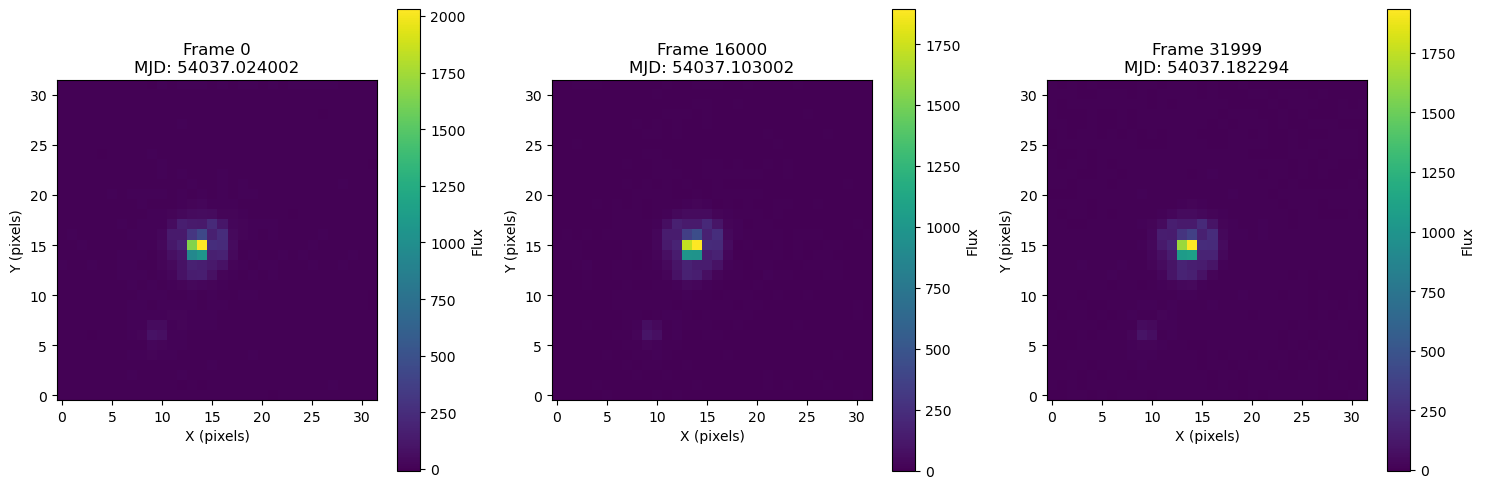


PART 6: Creating Boolean mask array
Mask array shape: (32000, 32, 32)
All pixels initialized to True (good)

PART 7: Calculating and subtracting median backgrounds

Median background statistics:
  Min: 0.5256
  Max: 9.7061
  Mean: 4.5707
  Std: 0.5221

Frame parameters array shape: (32000, 5)
  Column 4 now contains median background values


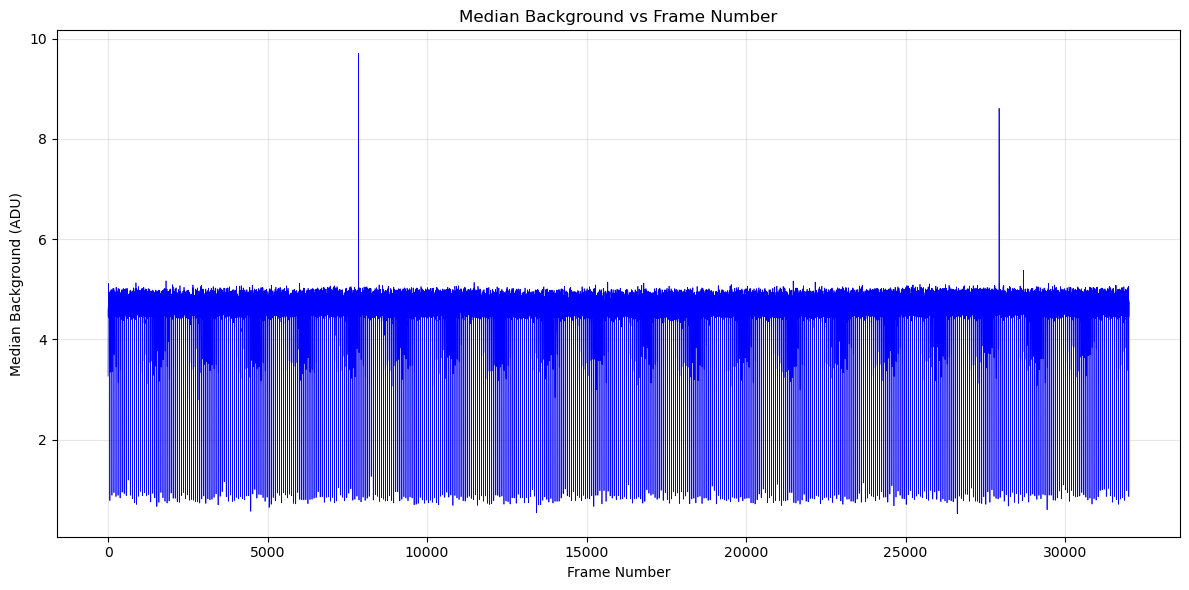


VERIFICATION COMPLETE

✓ Part 4(a): Read first data block - COMPLETE
✓ Part 4(b): Allocated data structures - COMPLETE
  - Data cube shape: (32000, 32, 32)
  - Frame params shape: (32000, 5)
✓ Part 4(c): Looped and populated data - COMPLETE
  - Processed 32000 frames
  - Timing calculated using MJD_OBS + EXPTIME/2
✓ Part 5: Data verification - COMPLETE
✓ Part 6: Boolean mask created - COMPLETE
  - Mask shape: (32000, 32, 32)
✓ Part 7: Median background subtraction - COMPLETE
  - Column 4 added to frame_params

Frame parameters array columns:
  Column 0: Frame number
  Column 1: Mid-time (MJD)
  Column 2: Exposure time (seconds)
  Column 3: Frame interval (seconds)
  Column 4: Median background (ADU)


In [10]:
# ===================================================================
# MAIN VERIFICATION SCRIPT
# ===================================================================

if __name__ == "__main__":
    
    # Set this to True to run verification
    RUN_VERIFICATION = True
    
    if RUN_VERIFICATION:
        print("=" * 60)
        print("COMPLETE VERIFICATION: Parts 4-7")
        print("=" * 60)
        
        # PART 4: Process data from set 187 to 686 (inclusive)
        data_cube, frame_params, header = process_spitzer_data(
            start_set=187,
            num_sets=500  # 686 - 187 + 1 = 500
        )
        
        # PART 5: Verify the data
        verify_data(data_cube, frame_params)
        
        # PART 6: Create mask array
        mask = create_mask_array(data_cube)
        
        # PART 7: Calculate and subtract median backgrounds
        data_cube, frame_params, median_backgrounds = calculate_and_subtract_median_background(
            data_cube, mask, frame_params
        )
        
        # Plot median background
        plot_median_background(frame_params, median_backgrounds)
        
        # Final summary
        print("\n" + "=" * 60)
        print("VERIFICATION COMPLETE")
        print("=" * 60)
        print(f"\n✓ Part 4(a): Read first data block - COMPLETE")
        print(f"✓ Part 4(b): Allocated data structures - COMPLETE")
        print(f"  - Data cube shape: {data_cube.shape}")
        print(f"  - Frame params shape: {frame_params.shape}")
        print(f"✓ Part 4(c): Looped and populated data - COMPLETE")
        print(f"  - Processed {frame_params.shape[0]} frames")
        print(f"  - Timing calculated using MJD_OBS + EXPTIME/2")
        print(f"✓ Part 5: Data verification - COMPLETE")
        print(f"✓ Part 6: Boolean mask created - COMPLETE")
        print(f"  - Mask shape: {mask.shape}")
        print(f"✓ Part 7: Median background subtraction - COMPLETE")
        print(f"  - Column 4 added to frame_params")
        
        print(f"\nFrame parameters array columns:")
        print(f"  Column 0: Frame number")
        print(f"  Column 1: Mid-time (MJD)")
        print(f"  Column 2: Exposure time (seconds)")
        print(f"  Column 3: Frame interval (seconds)")
        print(f"  Column 4: Median background (ADU)")

PART 9: Finding bad pixels (EXTRA CREDIT - NO LOOPS)

Data cube shape: (32000, 32, 32)
Number of sets: 500
Frames per set: 64
Processing 1024 pixel locations simultaneously...
Reshaped data: (500, 32, 32, 64)
Performing sigma rejection on all 512000 pixel time series...

Sigma rejection complete!
Total bad pixels found: 2665 (0.008%)
Bad pixels per frame (mean): 0.1
Bad pixels per frame (max): 257


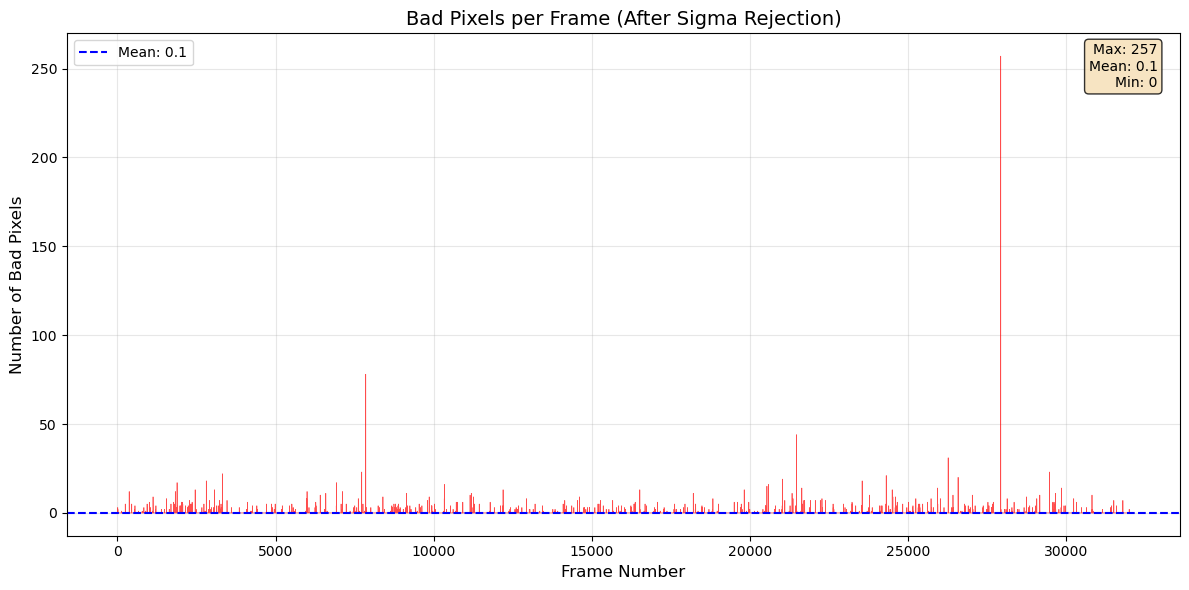

In [11]:
# ===================================================================
# PART 8: Sigma-rejection routine
# ===================================================================

def sigma_reject(data, sigma_threshold=5.0, max_iterations=2):
    """
    Perform sigma rejection on data array.
    
    Parameters:
    -----------
    data : ndarray
        Input data of any shape. The rejection is performed along the first axis.
    sigma_threshold : float
        Sigma threshold for rejection (default: 5.0)
    max_iterations : int
        Number of iterations (default: 2)
    
    Returns:
    --------
    mask : ndarray (bool)
        Boolean array where True = good, False = bad (same shape as data)
    """
    
    # Initialize mask to all True (all good)
    mask = np.ones(data.shape, dtype=bool)
    
    for iteration in range(max_iterations):
        # Use only good pixels for statistics
        good_data = np.where(mask, data, np.nan)
        
        # Calculate median and std along first axis, ignoring NaNs
        median = np.nanmedian(good_data, axis=0, keepdims=True)
        std = np.nanstd(good_data, axis=0, keepdims=True)
        
        # Calculate deviation from median
        deviation = np.abs(data - median)
        
        # Flag pixels that exceed threshold
        mask = mask & (deviation <= sigma_threshold * std)
    
    return mask


# ===================================================================
# PART 9: Find bad pixels (EXTRA CREDIT - NO LOOPS)
# ===================================================================

def find_bad_pixels_vectorized(data_cube, mask, sigma_threshold=5.0, frames_per_set=64):
    """
    Find bad pixels using sigma rejection with NO LOOPS (vectorized).
    
    This processes all pixels simultaneously by reshaping the data cube
    to group pixels by their spatial location across time.
    
    Parameters:
    -----------
    data_cube : ndarray
        3D data cube with shape (n_frames, height, width)
    mask : ndarray (bool)
        Boolean mask to update
    sigma_threshold : float
        Sigma threshold for rejection (default: 5.0)
    frames_per_set : int
        Number of frames per set (default: 64)
    
    Returns:
    --------
    data_cube : ndarray
        Data cube with bad pixels set to 0
    mask : ndarray
        Updated mask array
    n_bad_per_frame : ndarray
        Number of bad pixels found in each frame
    """
    
    print("=" * 60)
    print("PART 9: Finding bad pixels (EXTRA CREDIT - NO LOOPS)")
    print("=" * 60)
    
    n_frames, height, width = data_cube.shape
    n_sets = n_frames // frames_per_set
    
    print(f"\nData cube shape: {data_cube.shape}")
    print(f"Number of sets: {n_sets}")
    print(f"Frames per set: {frames_per_set}")
    print(f"Processing {height * width} pixel locations simultaneously...")
    
    # Reshape data to group by sets and pixel location
    # New shape: (n_sets, frames_per_set, height, width)
    reshaped_data = data_cube[:n_sets * frames_per_set].reshape(n_sets, frames_per_set, height, width)
    
    # Transpose to: (n_sets, height, width, frames_per_set)
    # This groups all 64 time samples for each pixel location together
    reshaped_data = np.transpose(reshaped_data, (0, 2, 3, 1))
    
    print(f"Reshaped data: {reshaped_data.shape}")
    print(f"Performing sigma rejection on all {n_sets * height * width} pixel time series...")
    
    # Reshape to (n_sets * height * width, frames_per_set)
    # Each row is a time series for one pixel location in one set
    pixel_timeseries = reshaped_data.reshape(-1, frames_per_set)
    
    # Transpose so each column is a time series
    pixel_timeseries = pixel_timeseries.T  # Now shape: (frames_per_set, n_sets * height * width)
    
    # Apply sigma rejection
    rejection_mask = sigma_reject(pixel_timeseries, sigma_threshold=sigma_threshold)
    
    # Transpose back
    rejection_mask = rejection_mask.T  # Shape: (n_sets * height * width, frames_per_set)
    
    # Reshape back to original structure
    rejection_mask = rejection_mask.reshape(n_sets, height, width, frames_per_set)
    
    # Transpose back to (n_sets, frames_per_set, height, width)
    rejection_mask = np.transpose(rejection_mask, (0, 3, 1, 2))
    
    # Reshape to match original data cube
    rejection_mask = rejection_mask.reshape(n_sets * frames_per_set, height, width)
    
    # Update the main mask
    mask[:n_sets * frames_per_set] = mask[:n_sets * frames_per_set] & rejection_mask
    
    # Set bad pixels to 0 in data cube
    data_cube[~mask] = 0
    
    # Calculate number of bad pixels per frame
    n_bad_per_frame = np.sum(~mask, axis=(1, 2))
    
    # Statistics
    total_bad = np.sum(~rejection_mask)
    total_pixels = rejection_mask.size
    percent_bad = 100 * total_bad / total_pixels
    
    print(f"\nSigma rejection complete!")
    print(f"Total bad pixels found: {total_bad} ({percent_bad:.3f}%)")
    print(f"Bad pixels per frame (mean): {np.mean(n_bad_per_frame):.1f}")
    print(f"Bad pixels per frame (max): {np.max(n_bad_per_frame)}")
    
    return data_cube, mask, n_bad_per_frame


def plot_bad_pixels_vs_frame(n_bad_per_frame, frame_params):
    """
    Plot number of bad pixels vs frame number.
    
    Parameters:
    -----------
    n_bad_per_frame : ndarray
        Number of bad pixels in each frame
    frame_params : ndarray
        Frame parameters array
    """
    
    frame_numbers = frame_params[:len(n_bad_per_frame), 0]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    ax.plot(frame_numbers, n_bad_per_frame, 'r-', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Frame Number', fontsize=12)
    ax.set_ylabel('Number of Bad Pixels', fontsize=12)
    ax.set_title('Bad Pixels per Frame (After Sigma Rejection)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_bad = np.mean(n_bad_per_frame)
    max_bad = np.max(n_bad_per_frame)
    
    ax.axhline(mean_bad, color='blue', linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_bad:.1f}')
    
    ax.legend(loc='best')
    
    # Add text box with statistics
    stats_text = f'Max: {max_bad}\nMean: {mean_bad:.1f}\nMin: {np.min(n_bad_per_frame)}'
    ax.text(0.98, 0.98, stats_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()


# ===================================================================
# Apply to actual data from previous steps
# ===================================================================

# Apply sigma rejection to find bad pixels
data_cube, mask, n_bad_per_frame = find_bad_pixels_vectorized(
    data_cube,
    mask,
    sigma_threshold=5.0,
    frames_per_set=64
)

# Plot the results
plot_bad_pixels_vs_frame(n_bad_per_frame, frame_params)

PART 10: Finding star centers

Finding initial star position in first frame...
Initial guess from brightest pixel: x=14, y=15
Fitted center in frame 0: x=13.588, y=14.782

Fitting all 32000 frames...
  Processed 1000/32000 frames...
  Processed 2000/32000 frames...
  Processed 3000/32000 frames...
  Processed 4000/32000 frames...
  Processed 5000/32000 frames...
  Processed 6000/32000 frames...
  Processed 7000/32000 frames...
  Processed 8000/32000 frames...
  Processed 9000/32000 frames...
  Processed 10000/32000 frames...
  Processed 11000/32000 frames...
  Processed 12000/32000 frames...
  Processed 13000/32000 frames...
  Processed 14000/32000 frames...
  Processed 15000/32000 frames...
  Processed 16000/32000 frames...
  Processed 17000/32000 frames...
  Processed 18000/32000 frames...
  Processed 19000/32000 frames...
  Processed 20000/32000 frames...
  Processed 21000/32000 frames...
  Processed 22000/32000 frames...
  Processed 23000/32000 frames...
  Processed 24000/32000 fra

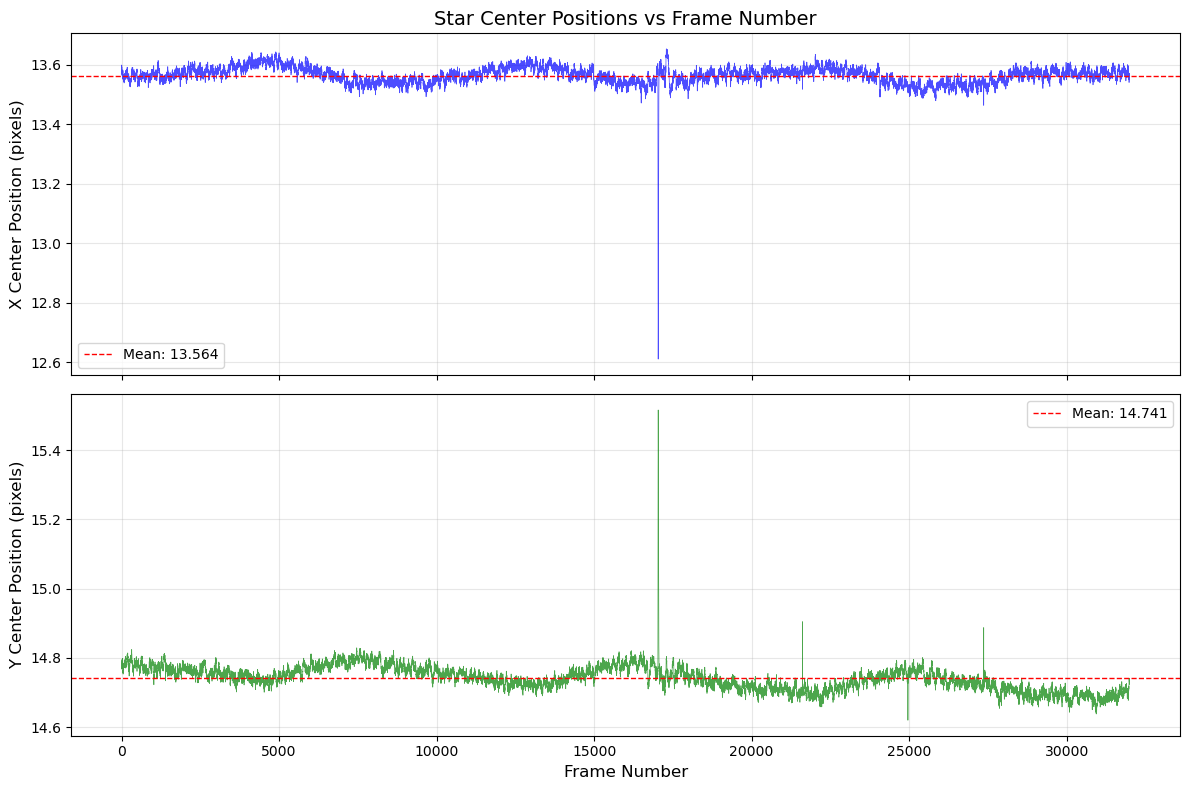

PART 11: Finding companion star offset

Creating median image from all frames...
Median image created
Program star mean position: x=13.564, y=14.741

Companion star found at: x=9.000, y=6.000
Offset from program star: dx=-4.564, dy=-8.741
Separation: 9.861 pixels


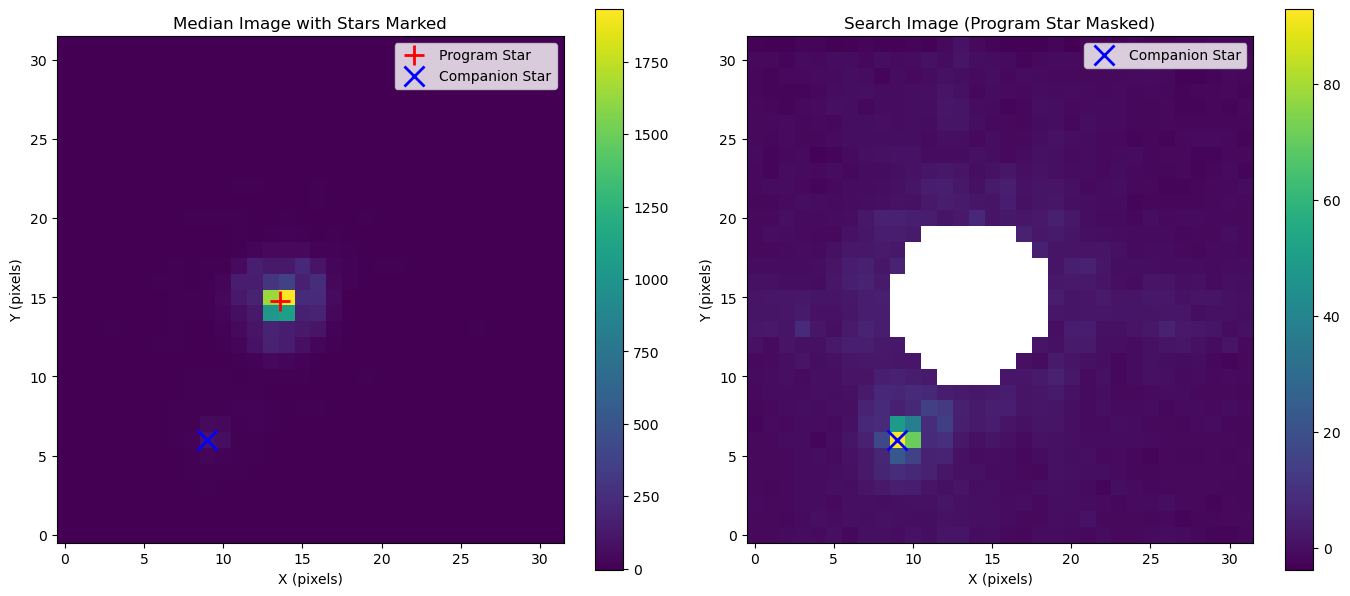


Masking companion star in all frames...
Companion star masked with radius=5 pixels
Total masked pixels: 2402182

PARTS 10-11 COMPLETE

✓ Part 10: Star centers found and recorded
  - Added columns 5 (x) and 6 (y) to frame_params
  - Plotted x and y positions vs frame number

✓ Part 11: Companion star masked
  - Companion offset: dx=-4.564, dy=-8.741 pixels
  - Companion masked in all frames


In [12]:
# ===================================================================
# PART 10: Find star centers using 2D Gaussian fitting
# ===================================================================

def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, offset):
    """
    2D Gaussian function.
    
    Parameters:
    -----------
    xy : tuple
        (x, y) coordinates as meshgrid arrays
    amplitude : float
        Peak amplitude
    x0, y0 : float
        Center position
    sigma_x, sigma_y : float
        Standard deviations in x and y
    offset : float
        Background offset
    
    Returns:
    --------
    g : ndarray
        2D Gaussian evaluated at xy positions
    """
    x, y = xy
    g = offset + amplitude * np.exp(-(((x - x0)**2 / (2 * sigma_x**2)) + 
                                       ((y - y0)**2 / (2 * sigma_y**2))))
    return g.ravel()


def fit_2d_gaussian(image, guess_x, guess_y, box_size=10):
    """
    Fit a 2D Gaussian to a region around the guessed position.
    
    Parameters:
    -----------
    image : ndarray
        2D image array
    guess_x, guess_y : float
        Initial guess for center position
    box_size : int
        Half-width of box around guess position
    
    Returns:
    --------
    x_center, y_center : float
        Fitted center position
    success : bool
        Whether fit was successful
    """
    
    height, width = image.shape
    
    # Define extraction box
    y_min = max(0, int(guess_y - box_size))
    y_max = min(height, int(guess_y + box_size + 1))
    x_min = max(0, int(guess_x - box_size))
    x_max = min(width, int(guess_x + box_size + 1))
    
    # Extract subimage
    subimage = image[y_min:y_max, x_min:x_max]
    
    # Create coordinate arrays
    y_sub, x_sub = np.mgrid[y_min:y_max, x_min:x_max]
    
    # Initial parameters
    amplitude_guess = np.max(subimage) - np.median(subimage)
    offset_guess = np.median(subimage)
    
    initial_guess = [amplitude_guess, guess_x, guess_y, 2.0, 2.0, offset_guess]
    
    try:
        # Fit the Gaussian
        popt, _ = curve_fit(gaussian_2d, (x_sub, y_sub), subimage.ravel(),
                           p0=initial_guess, maxfev=5000)
        
        x_center = popt[1]
        y_center = popt[2]
        
        # Check if fit is reasonable (within box)
        if (x_min <= x_center <= x_max) and (y_min <= y_center <= y_max):
            return x_center, y_center, True
        else:
            return guess_x, guess_y, False
            
    except:
        return guess_x, guess_y, False


def find_star_centers(data_cube, mask, frame_params, box_size=10):
    """
    Find star centers in all frames using 2D Gaussian fitting.
    
    Parameters:
    -----------
    data_cube : ndarray
        3D data cube
    mask : ndarray
        Boolean mask array
    frame_params : ndarray
        Frame parameters array (will add x, y center columns)
    box_size : int
        Half-width of fitting box
    
    Returns:
    --------
    frame_params : ndarray
        Updated with x and y center columns
    x_centers, y_centers : ndarray
        Arrays of center positions
    """
    
    print("=" * 60)
    print("PART 10: Finding star centers")
    print("=" * 60)
    
    n_frames = data_cube.shape[0]
    x_centers = np.zeros(n_frames)
    y_centers = np.zeros(n_frames)
    
    # Find approximate center in first frame
    print("\nFinding initial star position in first frame...")
    first_frame = data_cube[0].copy()
    first_frame[~mask[0]] = 0  # Use only good pixels
    
    # Find brightest pixel as initial guess
    y_guess, x_guess = np.unravel_index(np.argmax(first_frame), first_frame.shape)
    print(f"Initial guess from brightest pixel: x={x_guess}, y={y_guess}")
    
    # Fit first frame
    x_center, y_center, success = fit_2d_gaussian(first_frame, x_guess, y_guess, box_size)
    
    if success:
        print(f"Fitted center in frame 0: x={x_center:.3f}, y={y_center:.3f}")
    else:
        print(f"Fit failed for frame 0, using guess position")
    
    x_centers[0] = x_center
    y_centers[0] = y_center
    
    # Loop over remaining frames
    print(f"\nFitting all {n_frames} frames...")
    n_failed = 0
    
    for i in range(1, n_frames):
        # Use previous frame's center as guess
        frame = data_cube[i].copy()
        frame[~mask[i]] = 0
        
        x_center, y_center, success = fit_2d_gaussian(
            frame, x_centers[i-1], y_centers[i-1], box_size
        )
        
        if not success:
            n_failed += 1
        
        x_centers[i] = x_center
        y_centers[i] = y_center
        
        # Print progress every 1000 frames
        if (i + 1) % 1000 == 0:
            print(f"  Processed {i+1}/{n_frames} frames...")
    
    print(f"\nFitting complete!")
    print(f"  Successful fits: {n_frames - n_failed}")
    print(f"  Failed fits: {n_failed}")
    
    # Add centers to frame_params
    frame_params = np.column_stack([frame_params, x_centers, y_centers])
    
    print(f"\nFrame parameters array updated:")
    print(f"  New shape: {frame_params.shape}")
    print(f"  Column 5: x center position")
    print(f"  Column 6: y center position")
    
    # Statistics
    print(f"\nCenter position statistics:")
    print(f"  X: mean={np.mean(x_centers):.3f}, std={np.std(x_centers):.3f}")
    print(f"  Y: mean={np.mean(y_centers):.3f}, std={np.std(y_centers):.3f}")
    
    return frame_params, x_centers, y_centers


def plot_center_positions(frame_params, x_centers, y_centers):
    """
    Plot x and y center positions vs frame number.
    
    Parameters:
    -----------
    frame_params : ndarray
        Frame parameters array
    x_centers, y_centers : ndarray
        Center position arrays
    """
    
    frame_numbers = frame_params[:len(x_centers), 0]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot x positions
    ax1.plot(frame_numbers, x_centers, 'b-', linewidth=0.5, alpha=0.7)
    ax1.set_ylabel('X Center Position (pixels)', fontsize=12)
    ax1.set_title('Star Center Positions vs Frame Number', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Add mean line
    mean_x = np.mean(x_centers)
    ax1.axhline(mean_x, color='r', linestyle='--', linewidth=1,
                label=f'Mean: {mean_x:.3f}')
    ax1.legend(loc='best')
    
    # Plot y positions
    ax2.plot(frame_numbers, y_centers, 'g-', linewidth=0.5, alpha=0.7)
    ax2.set_xlabel('Frame Number', fontsize=12)
    ax2.set_ylabel('Y Center Position (pixels)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Add mean line
    mean_y = np.mean(y_centers)
    ax2.axhline(mean_y, color='r', linestyle='--', linewidth=1,
                label=f'Mean: {mean_y:.3f}')
    ax2.legend(loc='best')
    
    plt.tight_layout()
    plt.show()


# ===================================================================
# PART 11: Mask companion star
# ===================================================================

def find_companion_offset(data_cube, mask, x_centers, y_centers):
    """
    Find the offset of the companion star using median image.
    
    Parameters:
    -----------
    data_cube : ndarray
        3D data cube
    mask : ndarray
        Boolean mask array
    x_centers, y_centers : ndarray
        Program star center positions
    
    Returns:
    --------
    dx, dy : float
        Offset of companion from program star
    """
    
    print("=" * 60)
    print("PART 11: Finding companion star offset")
    print("=" * 60)
    
    # Create median image from all frames
    print("\nCreating median image from all frames...")
    masked_cube = data_cube.copy()
    masked_cube[~mask] = np.nan
    
    median_image = np.nanmedian(masked_cube, axis=0)
    
    print("Median image created")
    
    # Use mean star position as reference
    mean_x = np.mean(x_centers)
    mean_y = np.mean(y_centers)
    
    print(f"Program star mean position: x={mean_x:.3f}, y={mean_y:.3f}")
    
    # Find companion star (second brightest peak)
    # Mask out the program star first
    search_image = median_image.copy()
    
    # Mask region around program star
    y_indices, x_indices = np.ogrid[:search_image.shape[0], :search_image.shape[1]]
    distance_from_star = np.sqrt((x_indices - mean_x)**2 + (y_indices - mean_y)**2)
    search_image[distance_from_star < 5] = np.nan
    
    # Find brightest remaining pixel (companion star)
    companion_y, companion_x = np.unravel_index(
        np.nanargmax(search_image), search_image.shape
    )
    
    # Calculate offset
    dx = companion_x - mean_x
    dy = companion_y - mean_y
    
    print(f"\nCompanion star found at: x={companion_x:.3f}, y={companion_y:.3f}")
    print(f"Offset from program star: dx={dx:.3f}, dy={dy:.3f}")
    print(f"Separation: {np.sqrt(dx**2 + dy**2):.3f} pixels")
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Show median image
    im1 = ax1.imshow(median_image, origin='lower', cmap='viridis', interpolation='nearest')
    ax1.plot(mean_x, mean_y, 'r+', markersize=15, markeredgewidth=2, label='Program Star')
    ax1.plot(companion_x, companion_y, 'bx', markersize=15, markeredgewidth=2, label='Companion Star')
    ax1.set_title('Median Image with Stars Marked')
    ax1.set_xlabel('X (pixels)')
    ax1.set_ylabel('Y (pixels)')
    ax1.legend()
    plt.colorbar(im1, ax=ax1)
    
    # Show search image
    im2 = ax2.imshow(search_image, origin='lower', cmap='viridis', interpolation='nearest')
    ax2.plot(companion_x, companion_y, 'bx', markersize=15, markeredgewidth=2, label='Companion Star')
    ax2.set_title('Search Image (Program Star Masked)')
    ax2.set_xlabel('X (pixels)')
    ax2.set_ylabel('Y (pixels)')
    ax2.legend()
    plt.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()
    
    return dx, dy


def mask_companion_star(data_cube, mask, x_centers, y_centers, dx, dy, radius=5):
    """
    Mask the companion star in all frames.
    
    Parameters:
    -----------
    data_cube : ndarray
        3D data cube
    mask : ndarray
        Boolean mask array
    x_centers, y_centers : ndarray
        Program star centers
    dx, dy : float
        Companion offset from program star
    radius : float
        Radius of mask around companion
    
    Returns:
    --------
    data_cube : ndarray
        Data cube with companion masked
    mask : ndarray
        Updated mask array
    """
    
    print("\nMasking companion star in all frames...")
    
    n_frames = data_cube.shape[0]
    height, width = data_cube.shape[1], data_cube.shape[2]
    
    # Create coordinate grids
    y_grid, x_grid = np.ogrid[:height, :width]
    
    for i in range(n_frames):
        # Calculate companion position in this frame
        companion_x = x_centers[i] + dx
        companion_y = y_centers[i] + dy
        
        # Create circular mask around companion
        distance = np.sqrt((x_grid - companion_x)**2 + (y_grid - companion_y)**2)
        companion_mask = distance <= radius
        
        # Update mask and data
        mask[i][companion_mask] = False
        data_cube[i][companion_mask] = 0
    
    total_masked = np.sum(~mask)
    print(f"Companion star masked with radius={radius} pixels")
    print(f"Total masked pixels: {total_masked}")
    
    return data_cube, mask


# ===================================================================
# Apply to data
# ===================================================================

# Find star centers in all frames
frame_params, x_centers, y_centers = find_star_centers(
    data_cube, mask, frame_params, box_size=10
)

# Plot center positions
plot_center_positions(frame_params, x_centers, y_centers)

# Find companion star offset
dx, dy = find_companion_offset(data_cube, mask, x_centers, y_centers)

# Mask companion star
data_cube, mask = mask_companion_star(
    data_cube, mask, x_centers, y_centers, dx, dy, radius=5
)

print("\n" + "=" * 60)
print("PARTS 10-11 COMPLETE")
print("=" * 60)
print("\n✓ Part 10: Star centers found and recorded")
print(f"  - Added columns 5 (x) and 6 (y) to frame_params")
print(f"  - Plotted x and y positions vs frame number")
print("\n✓ Part 11: Companion star masked")
print(f"  - Companion offset: dx={dx:.3f}, dy={dy:.3f} pixels")
print(f"  - Companion masked in all frames")

PART 12: Performing aperture photometry on all frames

Photometry parameters:
  Aperture radius: 3.0 pixels
  Sky annulus: 5.0 to 8.0 pixels
  Number of frames: 32000
  Processed 1000/32000 frames...
  Processed 2000/32000 frames...
  Processed 3000/32000 frames...
  Processed 4000/32000 frames...
  Processed 5000/32000 frames...
  Processed 6000/32000 frames...
  Processed 7000/32000 frames...
  Processed 8000/32000 frames...
  Processed 9000/32000 frames...
  Processed 10000/32000 frames...
  Processed 11000/32000 frames...
  Processed 12000/32000 frames...
  Processed 13000/32000 frames...
  Processed 14000/32000 frames...
  Processed 15000/32000 frames...
  Processed 16000/32000 frames...
  Processed 17000/32000 frames...
  Processed 18000/32000 frames...
  Processed 19000/32000 frames...
  Processed 20000/32000 frames...
  Processed 21000/32000 frames...
  Processed 22000/32000 frames...
  Processed 23000/32000 frames...
  Processed 24000/32000 frames...
  Processed 25000/32000 fr

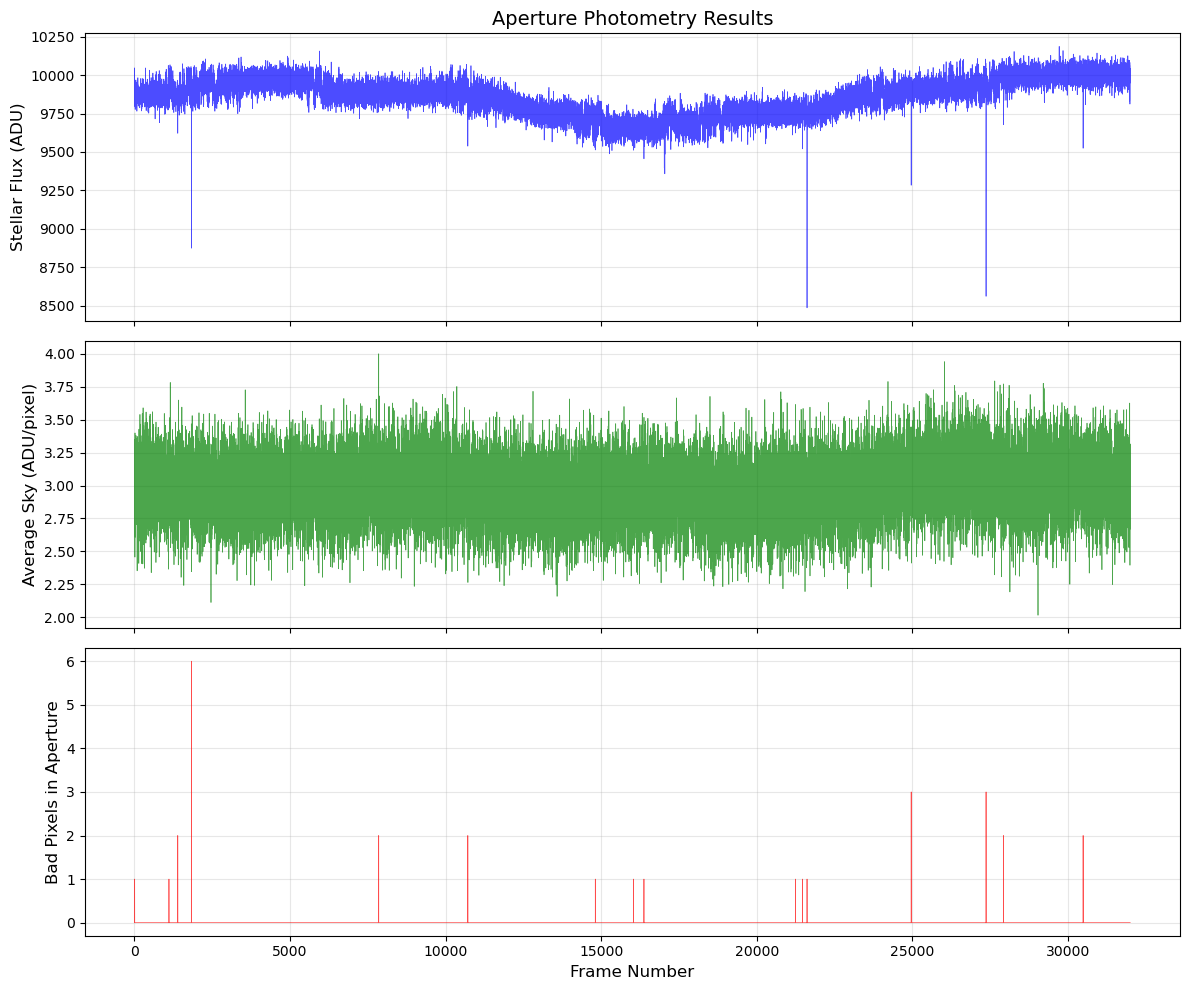


PART 12 COMPLETE

✓ Aperture photometry performed on all frames
  - Added columns 7, 8, 9 to frame_params
  - Column 7: Stellar flux
  - Column 8: Average sky
  - Column 9: Bad pixels in aperture

Frame parameters array shape: (32000, 10)


In [13]:
def disk(r, center, shape):
    '''
    Makes a bool array containing an N-dimensional ellipsoid mask.
    Parameters
    ----------
    r : scalar or N-dimensional tuple     
        The radii of the ellipsoid, may be fractional.  If N-dimensional,
        elliptical radii are specified in each dimension.  If scalar,
        same radius applies to all dimensions. 
    center : tuple
        Gives the position of the center of the ellipsoid, may be
        fractional and of any dimension.  Note that if the desired
        "ellipsoid" is 1D, specifying (20) on the command line results
        in an int, not a tuple containing an int.  Say (20,) to force a
        tuple containing an int.
    shape :  tuple, int
        Gives the shape of the output array.  Must be integer and same
        length as center.
    Returns
    -------
    output : boolean array
        This function returns a bool array containing an N-dimensional
        ellipsoid (line segment, filled ellipse, ellipsoid, etc.).
        The ellipsoid is centered at center and has the radii given by
        r.  Shape specifies the shape.  The type is bool.  Array
        values of 1 indicate that the center of a pixel is within the
        given ellipsoid.  Pixel values of 0 indicate the opposite.
        The center of each pixel is the integer position of that
        pixel.
    '''
    idisk      = np.indices(shape, dtype=float)
    cctr       = np.asarray(center).copy()
    sshape     = np.ones(1 + cctr.size, dtype=int)
    sshape[0]  = cctr.size
    cctr.shape = sshape
    rr         = np.asarray(r).copy()
    rshape     = np.ones(1 + rr.size, dtype=int)
    rshape[0]  = rr.size
    rr.shape   = rshape
    return np.sum(((idisk - cctr)/rr)**2, axis=0) <= 1.


def aperture_photometry(data, mask, center, r_aperture, r_inner, r_outer):
    """
    Perform aperture photometry with sky subtraction.
    
    Parameters:
    -----------
    data : ndarray (2D)
        Image data
    mask : ndarray (2D, bool)
        Bad pixel mask (True = good, False = bad)
    center : tuple
        (x, y) center position for photometry
    r_aperture : float
        Radius of photometry aperture
    r_inner : float
        Inner radius of sky annulus
    r_outer : float
        Outer radius of sky annulus
    
    Returns:
    --------
    result : ndarray (1D)
        Array containing [stellar_flux, average_sky, n_bad_pixels]
    """
    
    height, width = data.shape
    x_center, y_center = center
    
    # (a) Use disk twice to make mask for sky annulus
    outer_annulus = disk(r_outer, (y_center, x_center), (height, width))
    inner_annulus = disk(r_inner, (y_center, x_center), (height, width))
    sky_annulus = outer_annulus & ~inner_annulus
    
    # (b) Apply bad-pixel mask to sky annulus
    # Only use good pixels (mask=True) that are in the sky annulus
    good_sky_pixels = sky_annulus & mask
    
    # (c) Calculate average sky pixel in the annulus
    # Only use good pixels for sky estimate
    if np.sum(good_sky_pixels) > 0:
        sky_values = data[good_sky_pixels]
        average_sky = np.mean(sky_values)
    else:
        # No good sky pixels available
        average_sky = 0.0
    
    # (d) Subtract sky from each pixel in the image
    sky_subtracted = data - average_sky
    
    # (e) Use disk to make mask for photometry aperture
    # Do NOT apply the bad-pixel mask here
    aperture_mask = disk(r_aperture, (y_center, x_center), (height, width))
    
    # (f) Calculate total flux in aperture
    stellar_flux = np.sum(sky_subtracted[aperture_mask])
    
    # (g) Calculate total bad pixels in aperture
    bad_pixels_in_aperture = aperture_mask & ~mask
    n_bad_pixels = np.sum(bad_pixels_in_aperture)
    
    # Return results
    result = np.array([stellar_flux, average_sky, n_bad_pixels])
    
    return result


# ===================================================================
# Apply photometry to all frames
# ===================================================================

def photometry_all_frames(data_cube, mask, x_centers, y_centers, 
                          r_aperture=3.0, r_inner=5.0, r_outer=8.0):
    """
    Perform aperture photometry on all frames.
    
    Parameters:
    -----------
    data_cube : ndarray (3D)
        Data cube with all frames
    mask : ndarray (3D, bool)
        Bad pixel mask for all frames
    x_centers, y_centers : ndarray (1D)
        Star center positions for each frame
    r_aperture : float
        Radius of photometry aperture
    r_inner : float
        Inner radius of sky annulus
    r_outer : float
        Outer radius of sky annulus
    
    Returns:
    --------
    photometry_results : ndarray (2D)
        Array with shape (n_frames, 3) containing:
        [stellar_flux, average_sky, n_bad_pixels] for each frame
    """
    
    print("=" * 60)
    print("PART 12: Performing aperture photometry on all frames")
    print("=" * 60)
    
    n_frames = data_cube.shape[0]
    
    print(f"\nPhotometry parameters:")
    print(f"  Aperture radius: {r_aperture} pixels")
    print(f"  Sky annulus: {r_inner} to {r_outer} pixels")
    print(f"  Number of frames: {n_frames}")
    
    # Initialize results array
    photometry_results = np.zeros((n_frames, 3))
    
    # Loop over all frames
    for i in range(n_frames):
        center = (x_centers[i], y_centers[i])
        
        result = aperture_photometry(
            data_cube[i], 
            mask[i], 
            center, 
            r_aperture, 
            r_inner, 
            r_outer
        )
        
        photometry_results[i] = result
        
        # Print progress
        if (i + 1) % 1000 == 0:
            print(f"  Processed {i+1}/{n_frames} frames...")
    
    print(f"\nPhotometry complete!")
    
    # Statistics
    stellar_fluxes = photometry_results[:, 0]
    average_skies = photometry_results[:, 1]
    bad_pixel_counts = photometry_results[:, 2]
    
    print(f"\nResults summary:")
    print(f"  Stellar flux: mean={np.mean(stellar_fluxes):.2f}, "
          f"std={np.std(stellar_fluxes):.2f}")
    print(f"  Average sky: mean={np.mean(average_skies):.4f}, "
          f"std={np.std(average_skies):.4f}")
    print(f"  Bad pixels in aperture: mean={np.mean(bad_pixel_counts):.1f}, "
          f"max={np.max(bad_pixel_counts):.0f}")
    
    return photometry_results


def plot_photometry_results(photometry_results, frame_params):
    """
    Plot photometry results.
    
    Parameters:
    -----------
    photometry_results : ndarray
        Photometry results array
    frame_params : ndarray
        Frame parameters array
    """
    
    import matplotlib.pyplot as plt
    
    frame_numbers = frame_params[:len(photometry_results), 0]
    stellar_fluxes = photometry_results[:, 0]
    average_skies = photometry_results[:, 1]
    bad_pixel_counts = photometry_results[:, 2]
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # Plot stellar flux
    axes[0].plot(frame_numbers, stellar_fluxes, 'b-', linewidth=0.5, alpha=0.7)
    axes[0].set_ylabel('Stellar Flux (ADU)', fontsize=12)
    axes[0].set_title('Aperture Photometry Results', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # Plot average sky
    axes[1].plot(frame_numbers, average_skies, 'g-', linewidth=0.5, alpha=0.7)
    axes[1].set_ylabel('Average Sky (ADU/pixel)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    # Plot bad pixels in aperture
    axes[2].plot(frame_numbers, bad_pixel_counts, 'r-', linewidth=0.5, alpha=0.7)
    axes[2].set_xlabel('Frame Number', fontsize=12)
    axes[2].set_ylabel('Bad Pixels in Aperture', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ===================================================================
# PART 13: Photometry on all frames
# ===================================================================

# Perform photometry on all frames
photometry_results = photometry_all_frames(
    data_cube, 
    mask, 
    x_centers, 
    y_centers,
    r_aperture=3.0,
    r_inner=5.0,
    r_outer=8.0
)

# Plot results
plot_photometry_results(photometry_results, frame_params)

# Add photometry results to frame_params
frame_params = np.column_stack([
    frame_params,
    photometry_results[:, 0],  # stellar flux
    photometry_results[:, 1],  # average sky
    photometry_results[:, 2]   # bad pixels
])

print("\n" + "=" * 60)
print("PART 12 COMPLETE")
print("=" * 60)
print("\n✓ Aperture photometry performed on all frames")
print(f"  - Added columns 7, 8, 9 to frame_params")
print(f"  - Column 7: Stellar flux")
print(f"  - Column 8: Average sky")
print(f"  - Column 9: Bad pixels in aperture")
print(f"\nFrame parameters array shape: {frame_params.shape}")


PART 14: Analyzing photometry quality

------------------------------------------------------------
Initial statistics:
------------------------------------------------------------
Total frames: 32000
Frames with bad pixels in aperture: 17
Frames with zero bad pixels: 31983

------------------------------------------------------------
Identifying outlier frames:
------------------------------------------------------------

1. Frames with bad pixels in aperture: 17
   Reason: Bad pixels contaminate photometry

3. Frames with large star motion: 28
   Reason: Centroid >5σ from median (reaction wheel adjustments)

4. Frames with extreme flux values: 4
   Reason: Flux >5σ from median (cosmic rays or detector glitches)

------------------------------------------------------------
Summary:
------------------------------------------------------------
Good frames: 31955 (99.9%)
Flagged frames: 45 (0.1%)

------------------------------------------------------------
Inspecting frames with most b

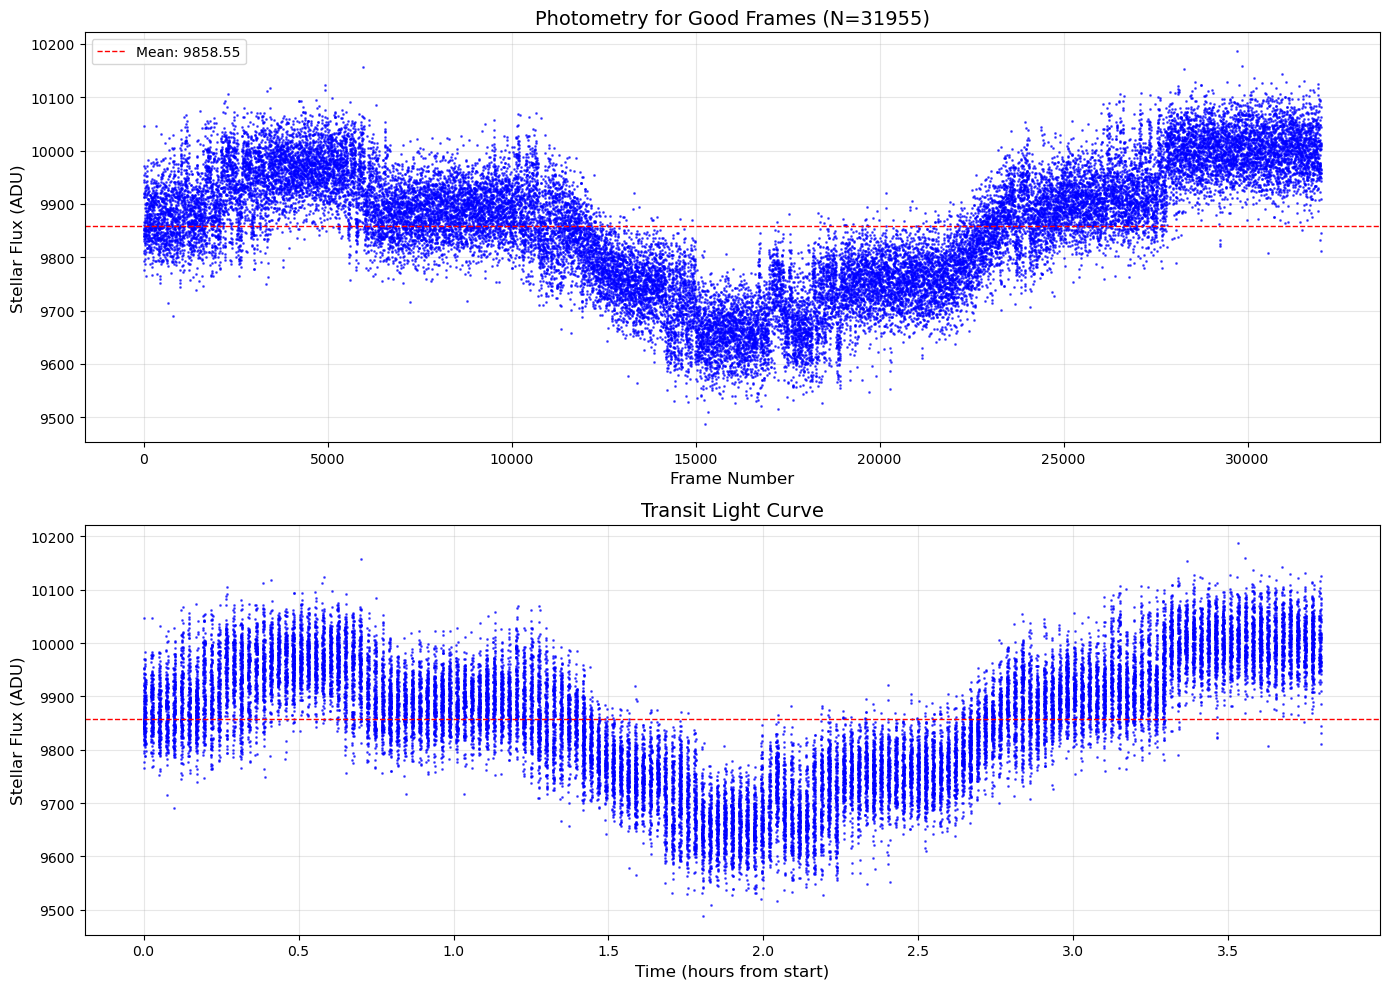


Light curve statistics:
  Mean flux: 9858.55
  Std dev: 116.01 (1.18%)
  Range: 698.81 (7.09%)

✓ Transit likely visible! Flux variation exceeds 3σ


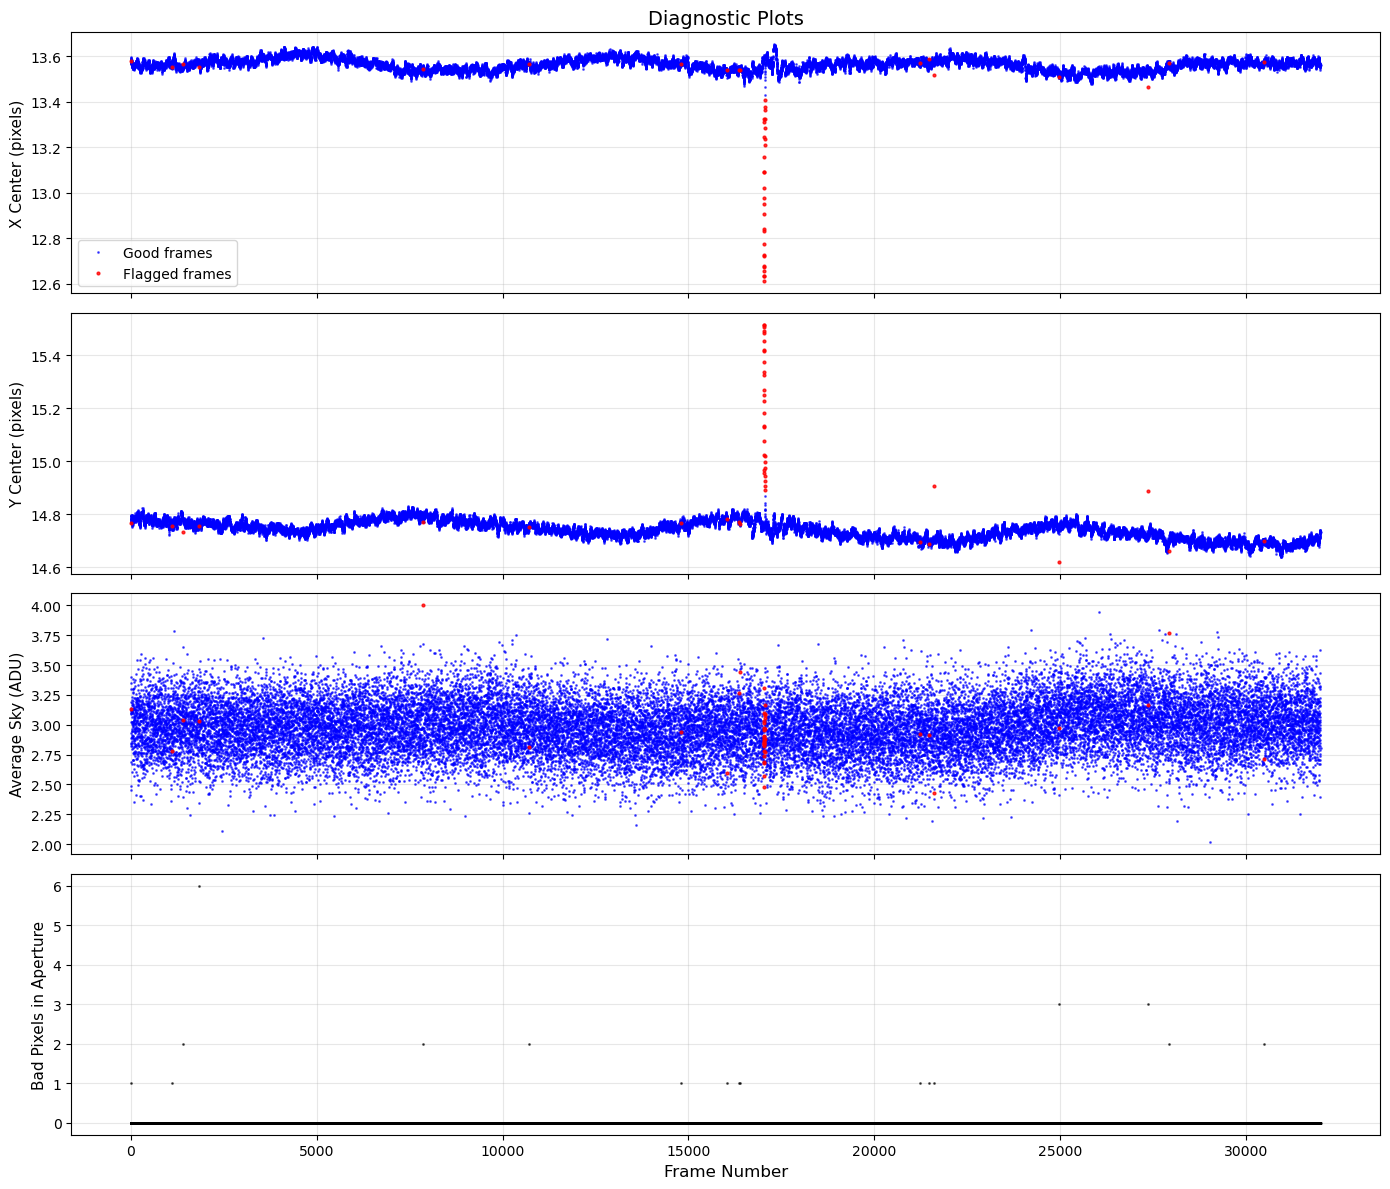


Visualizing worst frames:


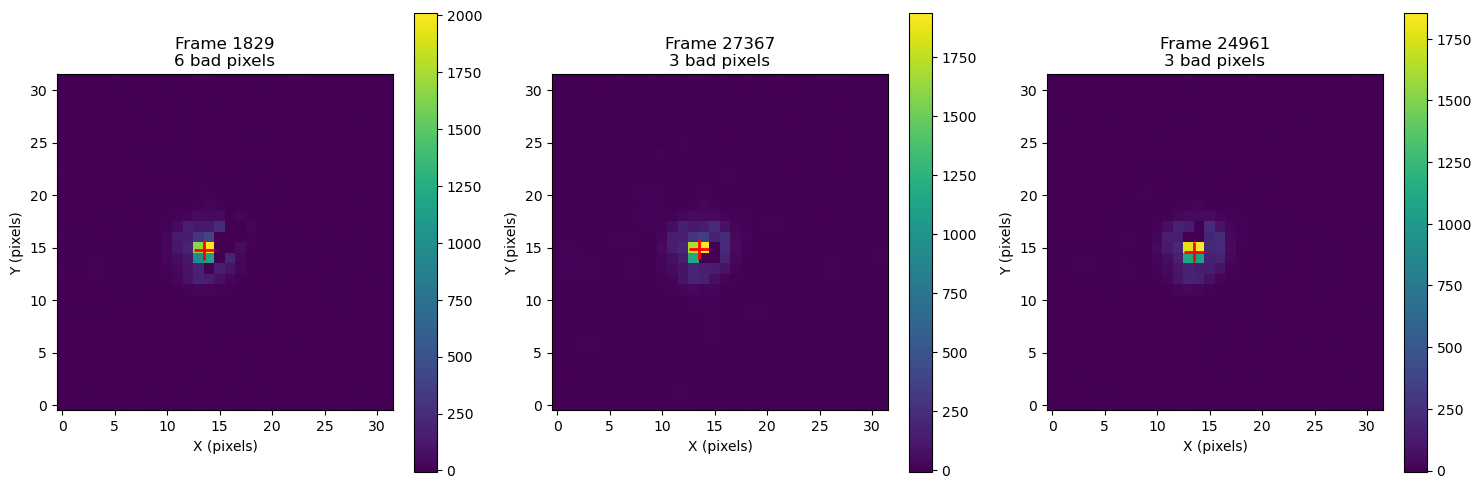


PART 14 COMPLETE

✓ Analyzed photometry quality
✓ Identified and flagged outlier frames
✓ Plotted photometry for good frames only
✓ Generated diagnostic plots
✓ Inspected worst frames


In [14]:
# ===================================================================
# PART 14: Check photometric outputs and identify outliers
# ===================================================================

def analyze_photometry_quality(frame_params, photometry_results):
    """
    Analyze photometry quality and identify outliers.
    
    Parameters:
    -----------
    frame_params : ndarray
        Frame parameters array
    photometry_results : ndarray
        Photometry results [flux, sky, bad_pixels]
    
    Returns:
    --------
    good_frames_mask : ndarray (bool)
        Mask where True = good frame, False = bad frame
    """
    
    print("\n" + "=" * 60)
    print("PART 14: Analyzing photometry quality")
    print("=" * 60)
    
    n_frames = len(photometry_results)
    
    stellar_fluxes = photometry_results[:, 0]
    average_skies = photometry_results[:, 1]
    bad_pixel_counts = photometry_results[:, 2]
    x_centers = frame_params[:n_frames, 5]
    y_centers = frame_params[:n_frames, 6]
    
    # Initialize all frames as good
    good_frames_mask = np.ones(n_frames, dtype=bool)
    
    # Statistics
    print("\n" + "-" * 60)
    print("Initial statistics:")
    print("-" * 60)
    print(f"Total frames: {n_frames}")
    print(f"Frames with bad pixels in aperture: {np.sum(bad_pixel_counts > 0)}")
    print(f"Frames with zero bad pixels: {np.sum(bad_pixel_counts == 0)}")
    
    # ===================================================================
    # Identify and flag outliers
    # ===================================================================
    
    print("\n" + "-" * 60)
    print("Identifying outlier frames:")
    print("-" * 60)
    
    # 1. Frames with bad pixels in aperture
    bad_pixel_frames = bad_pixel_counts > 0
    n_bad_pixel = np.sum(bad_pixel_frames)
    print(f"\n1. Frames with bad pixels in aperture: {n_bad_pixel}")
    print(f"   Reason: Bad pixels contaminate photometry")
    good_frames_mask &= ~bad_pixel_frames
    
    # Flag these with -1 in frame_params
    frame_params[bad_pixel_frames, 9] = -1
    
    # 2. High background (outliers in sky level)
    sky_median = np.median(average_skies)
    sky_std = np.std(average_skies)
    high_background = np.abs(average_skies - sky_median) > 5 * sky_std
    n_high_bg = np.sum(high_background)
    if n_high_bg > 0:
        print(f"\n2. Frames with very high/low background: {n_high_bg}")
        print(f"   Reason: Sky level >5σ from median (detector artifacts or spacecraft events)")
        good_frames_mask &= ~high_background
        frame_params[high_background, 9] = -1
    
    # 3. Large star motion (outliers in centroid position)
    x_median = np.median(x_centers)
    y_median = np.median(y_centers)
    x_std = np.std(x_centers)
    y_std = np.std(y_centers)
    
    large_x_motion = np.abs(x_centers - x_median) > 5 * x_std
    large_y_motion = np.abs(y_centers - y_median) > 5 * y_std
    large_motion = large_x_motion | large_y_motion
    n_large_motion = np.sum(large_motion)
    
    if n_large_motion > 0:
        print(f"\n3. Frames with large star motion: {n_large_motion}")
        print(f"   Reason: Centroid >5σ from median (reaction wheel adjustments)")
        good_frames_mask &= ~large_motion
        frame_params[large_motion, 9] = -1
    
    # 4. Flux outliers (cosmic ray hits on star or detector issues)
    flux_median = np.median(stellar_fluxes)
    flux_std = np.std(stellar_fluxes)
    flux_outliers = np.abs(stellar_fluxes - flux_median) > 5 * flux_std
    n_flux_outliers = np.sum(flux_outliers)
    
    if n_flux_outliers > 0:
        print(f"\n4. Frames with extreme flux values: {n_flux_outliers}")
        print(f"   Reason: Flux >5σ from median (cosmic rays or detector glitches)")
        good_frames_mask &= ~flux_outliers
        frame_params[flux_outliers, 9] = -1
    
    # ===================================================================
    # Summary
    # ===================================================================
    
    n_good = np.sum(good_frames_mask)
    n_bad = n_frames - n_good
    
    print("\n" + "-" * 60)
    print("Summary:")
    print("-" * 60)
    print(f"Good frames: {n_good} ({100*n_good/n_frames:.1f}%)")
    print(f"Flagged frames: {n_bad} ({100*n_bad/n_frames:.1f}%)")
    
    # ===================================================================
    # Inspect worst frames
    # ===================================================================
    
    print("\n" + "-" * 60)
    print("Inspecting frames with most bad pixels:")
    print("-" * 60)
    
    # Find frames with most bad pixels (excluding already flagged -1)
    original_bad_pixels = photometry_results[:, 2]
    worst_indices = np.argsort(original_bad_pixels)[-3:][::-1]
    
    for idx in worst_indices:
        print(f"\nFrame {idx}:")
        print(f"  Bad pixels in aperture: {original_bad_pixels[idx]:.0f}")
        print(f"  Stellar flux: {stellar_fluxes[idx]:.2f}")
        print(f"  Average sky: {average_skies[idx]:.4f}")
        print(f"  Center: x={x_centers[idx]:.3f}, y={y_centers[idx]:.3f}")
        
        if original_bad_pixels[idx] > 5:
            print(f"  Assessment: Significant contamination from bad pixels or hot pixels near star")
        elif original_bad_pixels[idx] > 2:
            print(f"  Assessment: Moderate bad pixel contamination")
        else:
            print(f"  Assessment: Minor bad pixel contamination")
    
    return good_frames_mask


def plot_good_frames_photometry(frame_params, photometry_results, good_frames_mask):
    """
    Plot photometry for good frames only.
    
    Parameters:
    -----------
    frame_params : ndarray
        Frame parameters array
    photometry_results : ndarray
        Photometry results
    good_frames_mask : ndarray (bool)
        Mask indicating good frames
    """
    
    print("\n" + "-" * 60)
    print("Plotting photometry for good frames:")
    print("-" * 60)
    
    n_frames = len(photometry_results)
    frame_numbers = frame_params[:n_frames, 0]
    times = frame_params[:n_frames, 1]  # MJD
    stellar_fluxes = photometry_results[:, 0]
    
    # Get good frames only
    good_frame_numbers = frame_numbers[good_frames_mask]
    good_times = times[good_frames_mask]
    good_fluxes = stellar_fluxes[good_frames_mask]
    
    # Convert time to hours from start
    time_hours = (good_times - good_times[0]) * 24
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Flux vs frame number
    axes[0].plot(good_frame_numbers, good_fluxes, 'b.', markersize=2, alpha=0.6)
    axes[0].set_xlabel('Frame Number', fontsize=12)
    axes[0].set_ylabel('Stellar Flux (ADU)', fontsize=12)
    axes[0].set_title(f'Photometry for Good Frames (N={len(good_fluxes)})', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # Add mean line
    mean_flux = np.mean(good_fluxes)
    axes[0].axhline(mean_flux, color='r', linestyle='--', linewidth=1,
                    label=f'Mean: {mean_flux:.2f}')
    axes[0].legend()
    
    # Plot 2: Flux vs time (transit light curve)
    axes[1].plot(time_hours, good_fluxes, 'b.', markersize=2, alpha=0.6)
    axes[1].set_xlabel('Time (hours from start)', fontsize=12)
    axes[1].set_ylabel('Stellar Flux (ADU)', fontsize=12)
    axes[1].set_title('Transit Light Curve', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(mean_flux, color='r', linestyle='--', linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    # Check if transit is visible
    flux_std = np.std(good_fluxes)
    flux_range = np.max(good_fluxes) - np.min(good_fluxes)
    
    print(f"\nLight curve statistics:")
    print(f"  Mean flux: {mean_flux:.2f}")
    print(f"  Std dev: {flux_std:.2f} ({100*flux_std/mean_flux:.2f}%)")
    print(f"  Range: {flux_range:.2f} ({100*flux_range/mean_flux:.2f}%)")
    
    if flux_range > 3 * flux_std:
        print(f"\n✓ Transit likely visible! Flux variation exceeds 3σ")
    else:
        print(f"\n  Transit may be present but subtle in raw photometry")


def plot_all_diagnostics(frame_params, photometry_results, good_frames_mask):
    """
    Plot diagnostic information for all frames.
    
    Parameters:
    -----------
    frame_params : ndarray
        Frame parameters array
    photometry_results : ndarray
        Photometry results
    good_frames_mask : ndarray (bool)
        Mask indicating good frames
    """
    
    n_frames = len(photometry_results)
    frame_numbers = frame_params[:n_frames, 0]
    x_centers = frame_params[:n_frames, 5]
    y_centers = frame_params[:n_frames, 6]
    stellar_fluxes = photometry_results[:, 0]
    average_skies = photometry_results[:, 1]
    bad_pixel_counts = photometry_results[:, 2]
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    
    # Mark bad frames in all plots
    bad_frames = ~good_frames_mask
    
    # Plot 1: X center
    axes[0].plot(frame_numbers[good_frames_mask], x_centers[good_frames_mask], 
                 'b.', markersize=2, alpha=0.6, label='Good frames')
    if np.sum(bad_frames) > 0:
        axes[0].plot(frame_numbers[bad_frames], x_centers[bad_frames], 
                     'r.', markersize=4, alpha=0.8, label='Flagged frames')
    axes[0].set_ylabel('X Center (pixels)', fontsize=11)
    axes[0].set_title('Diagnostic Plots', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Plot 2: Y center
    axes[1].plot(frame_numbers[good_frames_mask], y_centers[good_frames_mask], 
                 'b.', markersize=2, alpha=0.6)
    if np.sum(bad_frames) > 0:
        axes[1].plot(frame_numbers[bad_frames], y_centers[bad_frames], 
                     'r.', markersize=4, alpha=0.8)
    axes[1].set_ylabel('Y Center (pixels)', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Sky level
    axes[2].plot(frame_numbers[good_frames_mask], average_skies[good_frames_mask], 
                 'b.', markersize=2, alpha=0.6)
    if np.sum(bad_frames) > 0:
        axes[2].plot(frame_numbers[bad_frames], average_skies[bad_frames], 
                     'r.', markersize=4, alpha=0.8)
    axes[2].set_ylabel('Average Sky (ADU)', fontsize=11)
    axes[2].grid(True, alpha=0.3)
    
    # Plot 4: Bad pixels in aperture
    axes[3].plot(frame_numbers, bad_pixel_counts, 'k.', markersize=2, alpha=0.6)
    axes[3].set_xlabel('Frame Number', fontsize=12)
    axes[3].set_ylabel('Bad Pixels in Aperture', fontsize=11)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ===================================================================
# Apply to data
# ===================================================================

# Analyze photometry quality and identify outliers
good_frames_mask = analyze_photometry_quality(frame_params, photometry_results)

# Plot photometry for good frames only
plot_good_frames_photometry(frame_params, photometry_results, good_frames_mask)

# Plot all diagnostic information
plot_all_diagnostics(frame_params, photometry_results, good_frames_mask)

# Visualize a few of the worst frames
print("\n" + "=" * 60)
print("Visualizing worst frames:")
print("=" * 60)

original_bad_pixels = photometry_results[:, 2]
worst_indices = np.argsort(original_bad_pixels)[-3:][::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax_idx, frame_idx in enumerate(worst_indices):
    ax = axes[ax_idx]
    
    # Show the frame
    im = ax.imshow(data_cube[frame_idx], origin='lower', cmap='viridis', 
                   interpolation='nearest')
    
    # Mark the star center
    x_c = frame_params[frame_idx, 5]
    y_c = frame_params[frame_idx, 6]
    ax.plot(x_c, y_c, 'r+', markersize=15, markeredgewidth=2)
    
    ax.set_title(f'Frame {frame_idx}\n{original_bad_pixels[frame_idx]:.0f} bad pixels')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PART 14 COMPLETE")
print("=" * 60)
print("\n✓ Analyzed photometry quality")
print("✓ Identified and flagged outlier frames")
print("✓ Plotted photometry for good frames only")
print("✓ Generated diagnostic plots")
print("✓ Inspected worst frames")


Exploring different binning options...

Exploring different bin numbers:


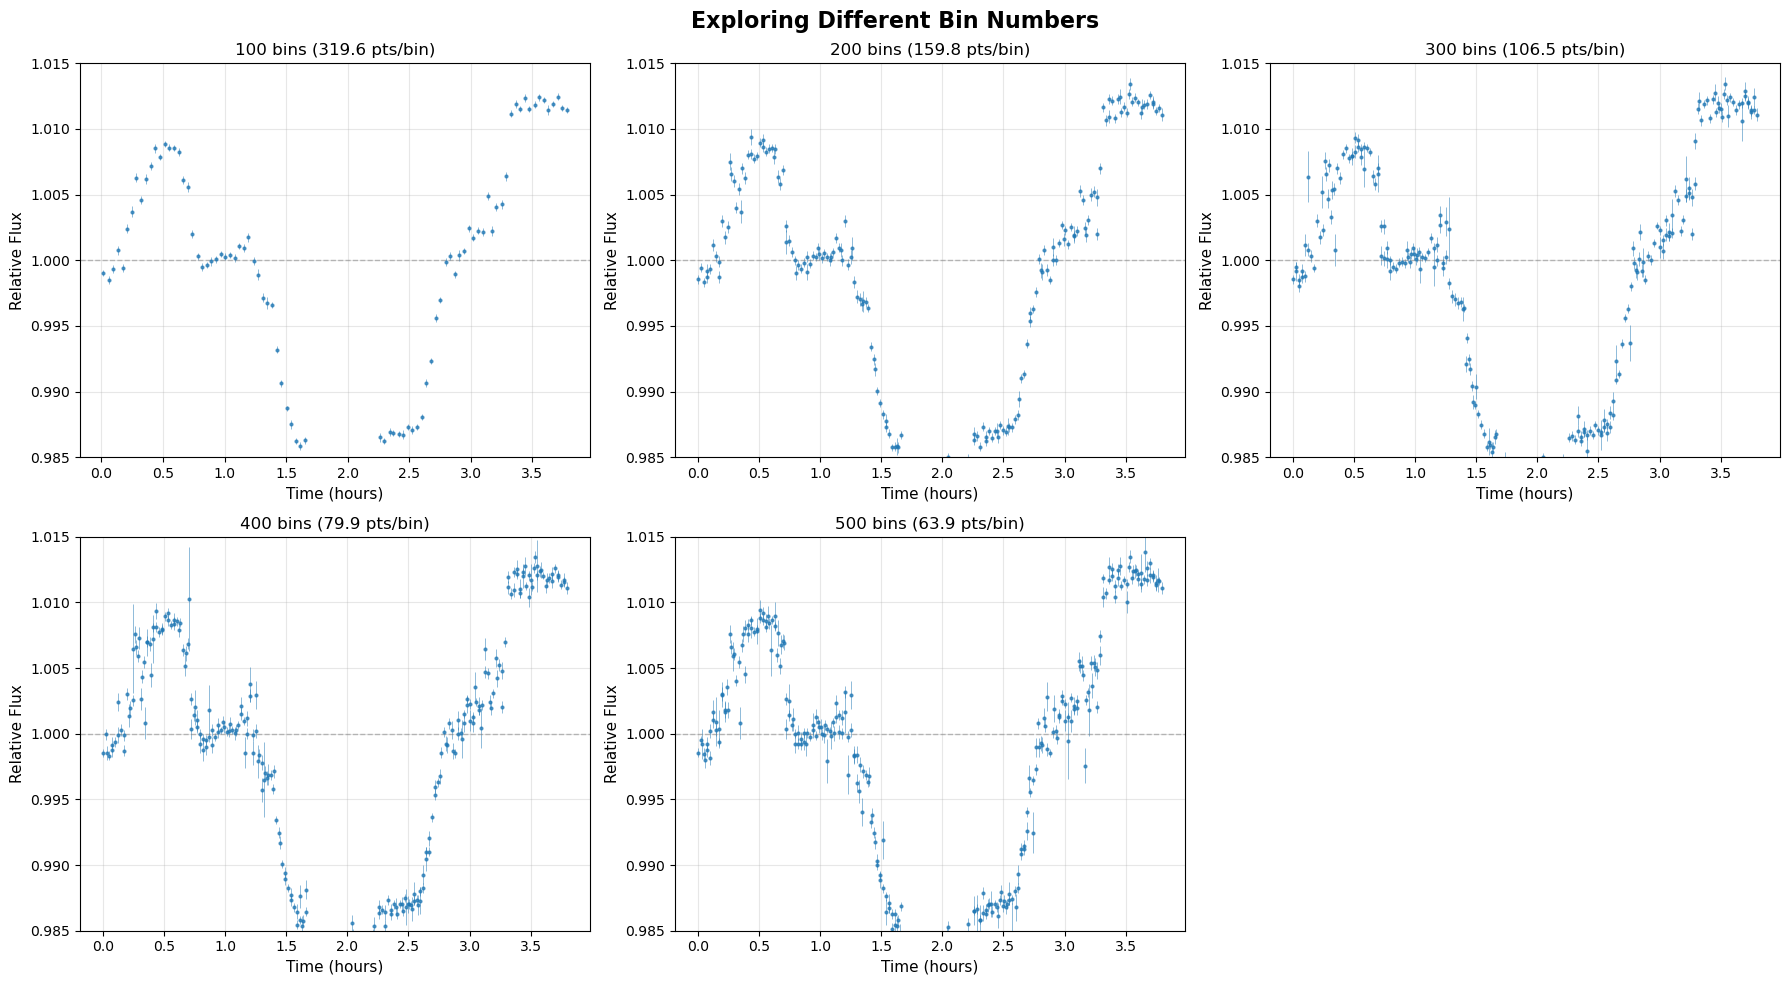


Creating final publication-ready plot:
PART 15: Binning data and creating publication plot

Binning data into 300 bins...
Bins created: 248
Points per bin (average): 106.5

Flux statistics:
  Median flux: 9885.18
  Flux range: 0.975364 to 1.013456
  Transit depth (approximate): 2.46%

✓ Saved figure as: transit_lightcurve.pdf


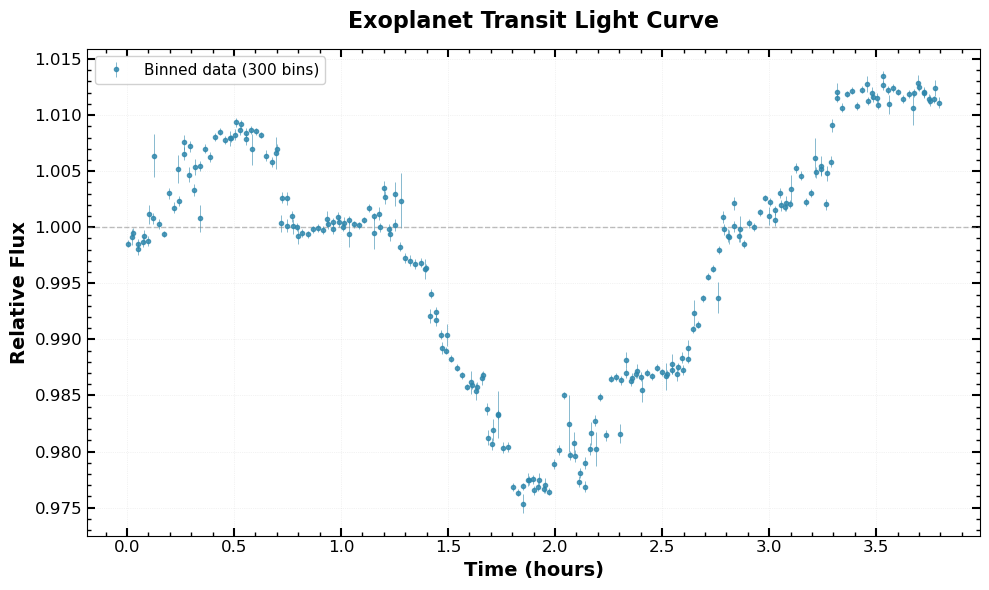


Creating zoomed version to show transit detail...

✓ Saved zoomed figure as: final_PKobrick_problem15_graph1.png


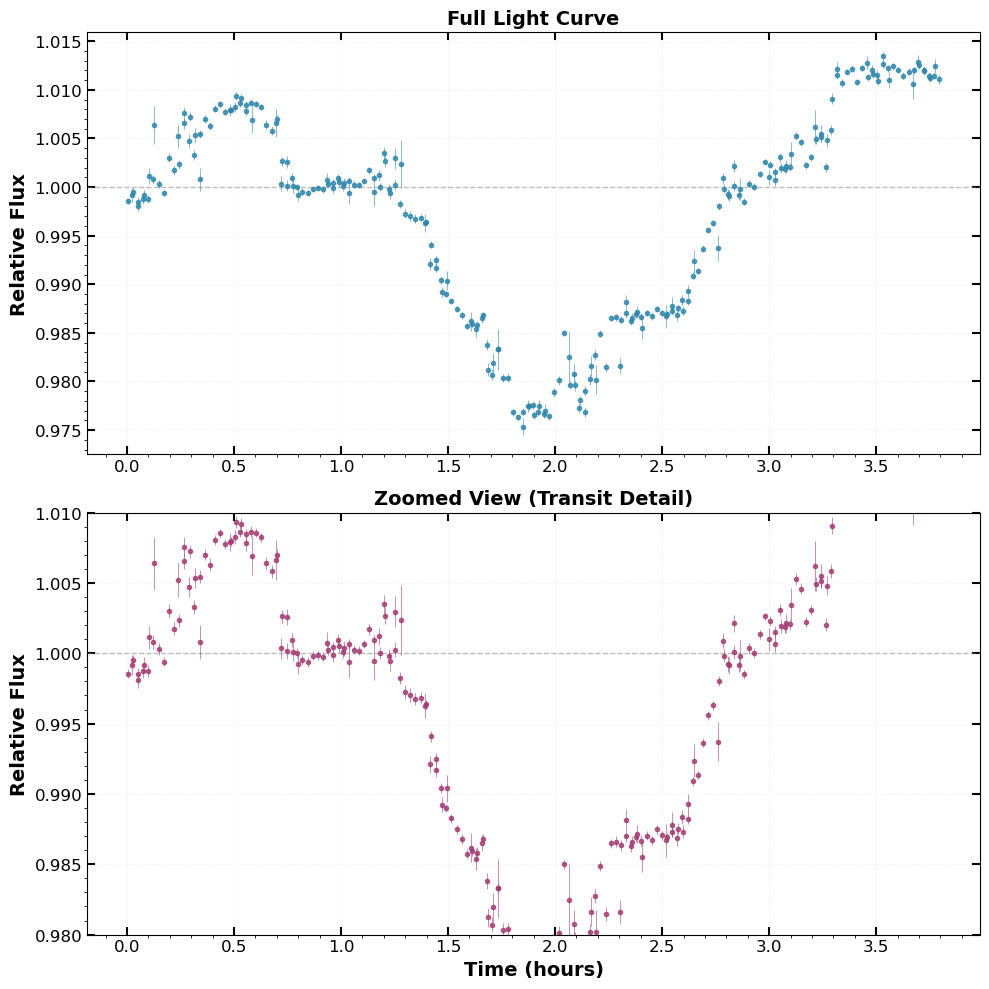


PART 15 COMPLETE

✓ Explored different bin numbers
✓ Created binned light curve
✓ Generated publication-ready plots
✓ Saved PDFs: transit_lightcurve.pdf and transit_lightcurve_zoomed.pdf


In [15]:
def bin_data(times, fluxes, n_bins):
    """
    Bin data by averaging into specified number of bins.
    
    Parameters:
    -----------
    times : ndarray
        Time values
    fluxes : ndarray
        Flux values
    n_bins : int
        Number of bins
    
    Returns:
    --------
    binned_times : ndarray
        Average time in each bin
    binned_fluxes : ndarray
        Average flux in each bin
    binned_errors : ndarray
        Standard error in each bin
    """
    
    # Sort by time
    sort_idx = np.argsort(times)
    times_sorted = times[sort_idx]
    fluxes_sorted = fluxes[sort_idx]
    
    # Calculate bin edges
    bin_edges = np.linspace(times_sorted[0], times_sorted[-1], n_bins + 1)
    
    # Initialize arrays
    binned_times = np.zeros(n_bins)
    binned_fluxes = np.zeros(n_bins)
    binned_errors = np.zeros(n_bins)
    
    # Bin the data
    for i in range(n_bins):
        # Find points in this bin
        in_bin = (times_sorted >= bin_edges[i]) & (times_sorted < bin_edges[i + 1])
        
        if i == n_bins - 1:  # Include right edge in last bin
            in_bin = (times_sorted >= bin_edges[i]) & (times_sorted <= bin_edges[i + 1])
        
        if np.sum(in_bin) > 0:
            binned_times[i] = np.mean(times_sorted[in_bin])
            binned_fluxes[i] = np.mean(fluxes_sorted[in_bin])
            binned_errors[i] = np.std(fluxes_sorted[in_bin]) / np.sqrt(np.sum(in_bin))
        else:
            # Empty bin - use NaN
            binned_times[i] = np.nan
            binned_fluxes[i] = np.nan
            binned_errors[i] = np.nan
    
    # Remove empty bins
    valid = ~np.isnan(binned_times)
    
    return binned_times[valid], binned_fluxes[valid], binned_errors[valid]


def plot_binned_lightcurve(times, fluxes, n_bins=300, save_pdf=True):
    """
    Plot binned light curve with publication-ready formatting.
    
    Parameters:
    -----------
    times : ndarray
        Time values (MJD)
    fluxes : ndarray
        Flux values
    n_bins : int
        Number of bins for averaging
    save_pdf : bool
        Whether to save as PDF
    """
    
    print("=" * 60)
    print("PART 15: Binning data and creating publication plot")
    print("=" * 60)
    
    # Convert time to hours from start
    time_hours = (times - times[0]) * 24
    
    # Bin the data
    print(f"\nBinning data into {n_bins} bins...")
    binned_times, binned_fluxes, binned_errors = bin_data(time_hours, fluxes, n_bins)
    
    print(f"Bins created: {len(binned_times)}")
    print(f"Points per bin (average): {len(fluxes) / n_bins:.1f}")
    
    # Normalize to relative flux (easier to see transit)
    median_flux = np.median(binned_fluxes)
    relative_flux = binned_fluxes / median_flux
    relative_errors = binned_errors / median_flux
    
    # Statistics
    print(f"\nFlux statistics:")
    print(f"  Median flux: {median_flux:.2f}")
    print(f"  Flux range: {np.min(relative_flux):.6f} to {np.max(relative_flux):.6f}")
    print(f"  Transit depth (approximate): {(1 - np.min(relative_flux)) * 100:.2f}%")
    
    # Create publication-ready figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plot binned data with error bars
    ax.errorbar(binned_times, relative_flux, yerr=relative_errors,
                fmt='o', markersize=3, color='#2E86AB', alpha=0.8,
                ecolor='#2E86AB', elinewidth=0.5, capsize=0,
                label=f'Binned data ({n_bins} bins)')
    
    # Add horizontal line at 1.0
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Labels and title
    ax.set_xlabel('Time (hours)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Relative Flux', fontsize=14, fontweight='bold')
    ax.set_title('Exoplanet Transit Light Curve', fontsize=16, fontweight='bold', pad=15)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    
    # Legend
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    # Tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12, direction='in',
                   top=True, right=True, length=6, width=1.5)
    ax.tick_params(axis='both', which='minor', direction='in',
                   top=True, right=True, length=3, width=1)
    
    # Add minor ticks
    ax.minorticks_on()
    
    # Tight layout
    plt.tight_layout()
    
    # Save as PDF
    if save_pdf:
        plt.savefig('transit_lightcurve.pdf', dpi=300, bbox_inches='tight')
        print("\n✓ Saved figure as: transit_lightcurve.pdf")
    
    plt.show()
    
    return binned_times, binned_fluxes, binned_errors


def explore_bin_numbers(times, fluxes, bin_options=[100, 200, 300, 400, 500]):
    """
    Explore different binning options to find optimal number of bins.
    
    Parameters:
    -----------
    times : ndarray
        Time values (MJD)
    fluxes : ndarray
        Flux values
    bin_options : list
        List of bin numbers to try
    """
    
    print("\n" + "=" * 60)
    print("Exploring different bin numbers:")
    print("=" * 60)
    
    # Convert time to hours from start
    time_hours = (times - times[0]) * 24
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, n_bins in enumerate(bin_options):
        ax = axes[idx]
        
        # Bin the data
        binned_times, binned_fluxes, binned_errors = bin_data(time_hours, fluxes, n_bins)
        
        # Normalize
        median_flux = np.median(binned_fluxes)
        relative_flux = binned_fluxes / median_flux
        relative_errors = binned_errors / median_flux
        
        # Plot
        ax.errorbar(binned_times, relative_flux, yerr=relative_errors,
                   fmt='o', markersize=2, alpha=0.7,
                   elinewidth=0.5, capsize=0)
        
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('Time (hours)', fontsize=11)
        ax.set_ylabel('Relative Flux', fontsize=11)
        ax.set_title(f'{n_bins} bins ({len(fluxes)/n_bins:.1f} pts/bin)', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Zoom to see transit better
        ax.set_ylim([0.985, 1.015])
    
    # Remove extra subplot
    if len(bin_options) < 6:
        axes[-1].remove()
    
    plt.suptitle('Exploring Different Bin Numbers', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def create_zoomed_transit_plot(times, fluxes, n_bins=300):
    """
    Create zoomed-in publication plot showing transit detail.
    
    Parameters:
    -----------
    times : ndarray
        Time values (MJD)
    fluxes : ndarray
        Flux values
    n_bins : int
        Number of bins
    """
    
    # Convert time to hours from start
    time_hours = (times - times[0]) * 24
    
    # Bin the data
    binned_times, binned_fluxes, binned_errors = bin_data(time_hours, fluxes, n_bins)
    
    # Normalize
    median_flux = np.median(binned_fluxes)
    relative_flux = binned_fluxes / median_flux
    relative_errors = binned_errors / median_flux
    
    # Create figure with two panels
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    
    # Panel 1: Full light curve
    ax1.errorbar(binned_times, relative_flux, yerr=relative_errors,
                fmt='o', markersize=3, color='#2E86AB', alpha=0.8,
                ecolor='#2E86AB', elinewidth=0.5, capsize=0)
    ax1.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_ylabel('Relative Flux', fontsize=14, fontweight='bold')
    ax1.set_title('Full Light Curve', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax1.tick_params(axis='both', which='major', labelsize=12, direction='in',
                    top=True, right=True, length=6, width=1.5)
    ax1.minorticks_on()
    
    # Panel 2: Zoomed to transit
    ax2.errorbar(binned_times, relative_flux, yerr=relative_errors,
                fmt='o', markersize=3, color='#A23B72', alpha=0.8,
                ecolor='#A23B72', elinewidth=0.5, capsize=0)
    ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Time (hours)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Relative Flux', fontsize=14, fontweight='bold')
    ax2.set_title('Zoomed View (Transit Detail)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax2.tick_params(axis='both', which='major', labelsize=12, direction='in',
                    top=True, right=True, length=6, width=1.5)
    ax2.minorticks_on()
    
    # Set zoom range (adjust as needed to show transit)
    ax2.set_ylim([0.980, 1.010])
    
    plt.tight_layout()
    plt.savefig('final_PKobrick_problem15_graph1.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved zoomed figure as: final_PKobrick_problem15_graph1.png")
    plt.show()


# ===================================================================
# Apply to data
# ===================================================================

# Get good frames only
good_times = frame_params[good_frames_mask, 1]  # MJD
good_fluxes = photometry_results[good_frames_mask, 0]

# First, explore different bin numbers
print("\nExploring different binning options...")
explore_bin_numbers(good_times, good_fluxes, bin_options=[100, 200, 300, 400, 500])

# Create final publication plot with chosen number of bins
print("\n" + "=" * 60)
print("Creating final publication-ready plot:")
print("=" * 60)

# Adjust n_bins as needed after exploring
n_bins_final = 300

binned_times, binned_fluxes, binned_errors = plot_binned_lightcurve(
    good_times, 
    good_fluxes, 
    n_bins=n_bins_final,
    save_pdf=True
)

# Create zoomed version
print("\nCreating zoomed version to show transit detail...")
create_zoomed_transit_plot(good_times, good_fluxes, n_bins=n_bins_final)

print("\n" + "=" * 60)
print("PART 15 COMPLETE")
print("=" * 60)
print("\n✓ Explored different bin numbers")
print("✓ Created binned light curve")
print("✓ Generated publication-ready plots")
print("✓ Saved PDFs: transit_lightcurve.pdf and transit_lightcurve_zoomed.pdf")

PART 16: Automatically identifying transit contacts


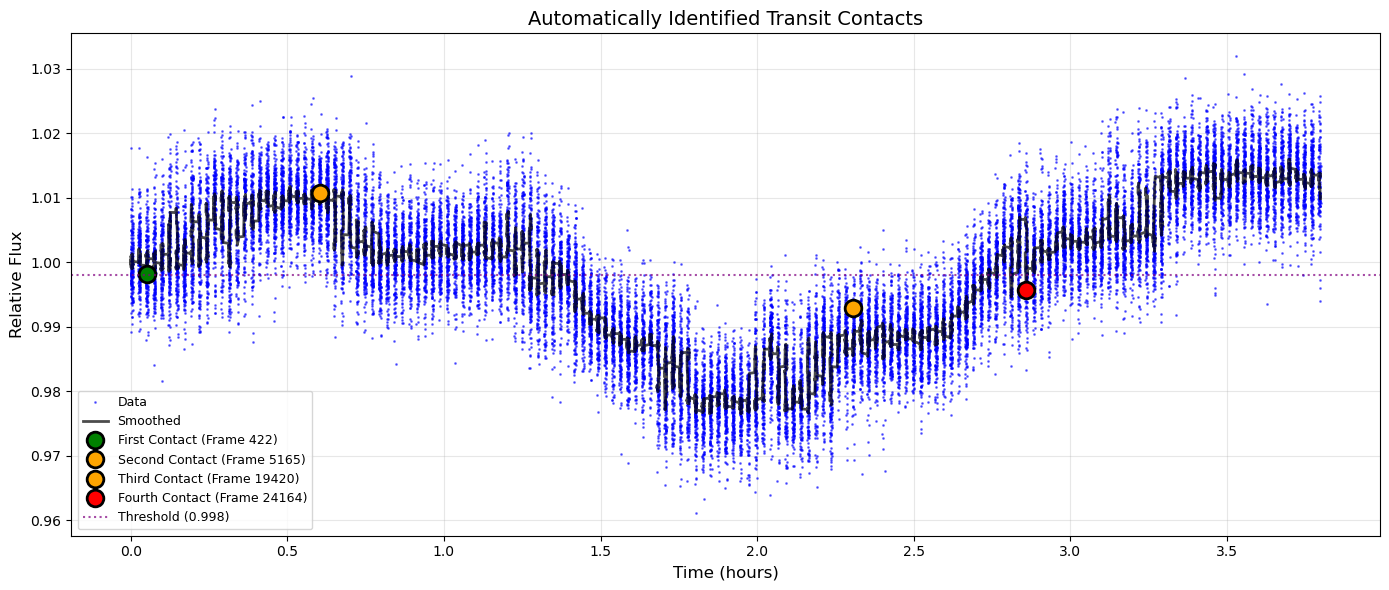


------------------------------------------------------------
Transit Contact Points Identified:
------------------------------------------------------------
First Contact (ingress start):  Frame 422
Second Contact (fully on disk):  Frame 5165
Third Contact (egress start):    Frame 19420
Fourth Contact (transit end):    Frame 24164
------------------------------------------------------------

PART 17: Fitting baseline parabola

Out-of-transit data points: 8252
In-transit data points: 23703

Fitting parabola (a*t^2 + b*t + c) to out-of-transit data...

Fitted parameters:
  a = 3.900180e+01
  b = -1.052375e+02
  c = 9874.144717

Fit quality (RMS of residuals): 53.1340

Normalizing all flux data with parabola model...
Normalization complete!
  Mean of normalized flux: 0.999603
  Std of normalized flux: 0.010113

------------------------------------------------------------
Creating publication-ready normalized light curve plot
------------------------------------------------------------
✓ 

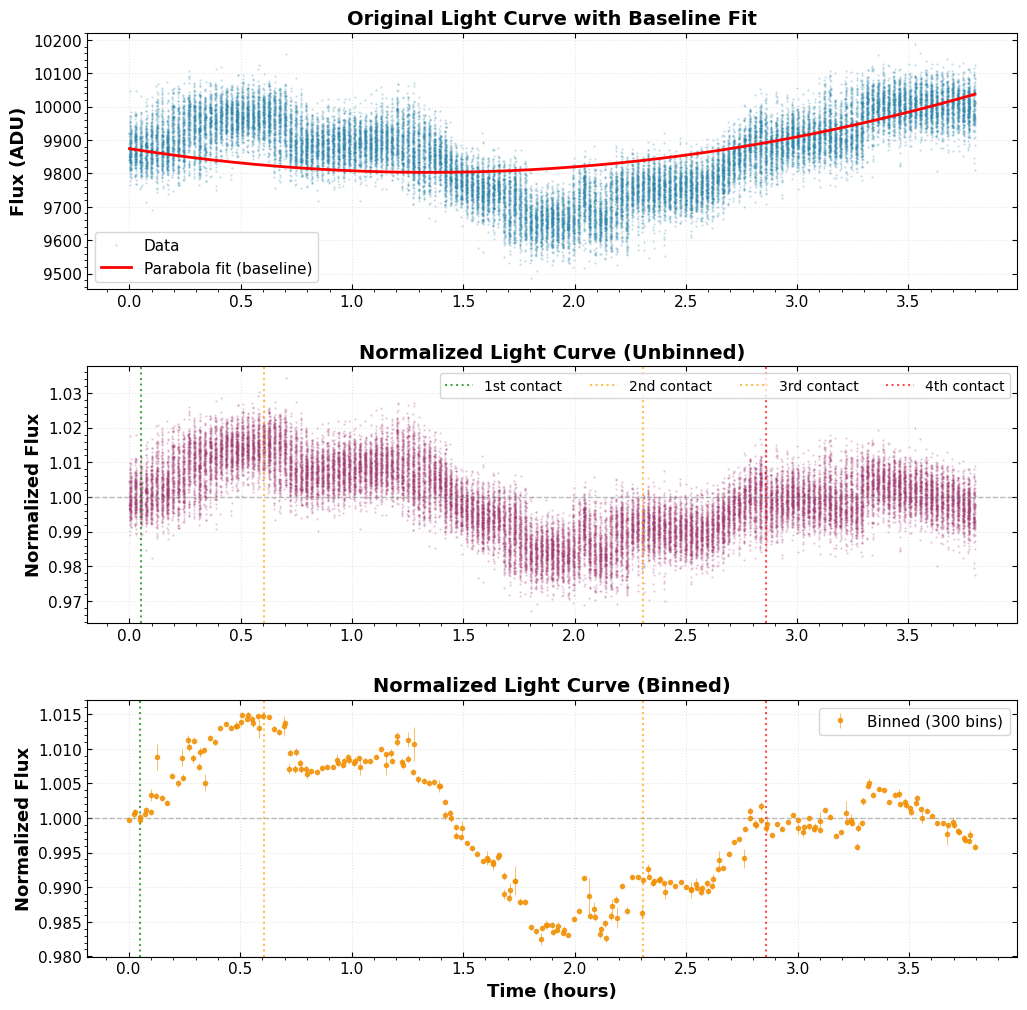


PARTS 16-17 COMPLETE

✓ Part 16: Transit contacts identified
✓ Part 17: Parabola fitted to out-of-transit data
✓ Part 17: All fluxes normalized with baseline model
✓ Part 17: Publication-ready plot saved


In [16]:
# ===================================================================
# PART 16: Manually identify transit contact points
# ===================================================================

def identify_transit_contacts(times, fluxes, frame_numbers):
    """
    Interactive function to identify transit contact points.
    
    Parameters:
    -----------
    times : ndarray
        Time values (hours from start)
    fluxes : ndarray
        Flux values
    frame_numbers : ndarray
        Frame numbers
    """
    
    print("=" * 60)
    print("PART 16: Identifying transit contact points")
    print("=" * 60)
    
    # Normalize flux
    median_flux = np.median(fluxes)
    relative_flux = fluxes / median_flux
    
    # Create interactive plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    
    ax.plot(times, relative_flux, 'b.', markersize=2, alpha=0.5)
    ax.set_xlabel('Time (hours)', fontsize=12)
    ax.set_ylabel('Relative Flux', fontsize=12)
    ax.set_title('Click to Identify Transit Contacts\n1st: First Contact, 2nd: Second Contact, 3rd: Third Contact, 4th: Fourth Contact', 
                 fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    plt.tight_layout()
    
    print("\nPlease click on the plot to identify the four contact points:")
    print("  1. First contact (start of transit)")
    print("  2. Second contact (planet fully on stellar disk)")
    print("  3. Third contact (start of egress)")
    print("  4. Fourth contact (end of transit)")
    
    # Get 4 clicks from user
    points = plt.ginput(4, timeout=0)
    
    # Find nearest frame for each click
    contact_times = [p[0] for p in points]
    contact_frames = []
    
    for ct in contact_times:
        # Find nearest frame
        idx = np.argmin(np.abs(times - ct))
        contact_frames.append(int(frame_numbers[idx]))
    
    # Mark contacts on plot
    colors = ['green', 'orange', 'orange', 'red']
    labels = ['First Contact', 'Second Contact', 'Third Contact', 'Fourth Contact']
    
    for i, (frame_idx, label, color) in enumerate(zip(contact_frames, labels, colors)):
        # Find this frame in the data
        idx = np.where(frame_numbers == frame_idx)[0][0]
        ax.plot(times[idx], relative_flux[idx], 'o', color=color, 
               markersize=12, markeredgecolor='black', markeredgewidth=2,
               label=f'{label} (Frame {frame_idx})')
    
    ax.legend(loc='best', fontsize=10)
    plt.show()
    
    print("\n" + "-" * 60)
    print("Transit Contact Points Identified:")
    print("-" * 60)
    print(f"First Contact (ingress start):  Frame {contact_frames[0]}")
    print(f"Second Contact (fully on disk):  Frame {contact_frames[1]}")
    print(f"Third Contact (egress start):    Frame {contact_frames[2]}")
    print(f"Fourth Contact (transit end):    Frame {contact_frames[3]}")
    print("-" * 60)
    
    return contact_frames


def identify_transit_contacts_automatic(times, fluxes, frame_numbers):
    """
    Automatically identify transit contact points based on flux minima.
    Use this if interactive clicking doesn't work.
    
    Parameters:
    -----------
    times : ndarray
        Time values (hours from start)
    fluxes : ndarray
        Flux values
    frame_numbers : ndarray
        Frame numbers
    """
    
    print("=" * 60)
    print("PART 16: Automatically identifying transit contacts")
    print("=" * 60)
    
    # Normalize flux
    median_flux = np.median(fluxes)
    relative_flux = fluxes / median_flux
    
    smoothed = uniform_filter1d(relative_flux, size=50)
    
    # Find minimum (deepest part of transit)
    min_idx = np.argmin(smoothed)
    
    # Find where flux drops below threshold (start and end of transit)
    threshold = 0.998  # Adjust as needed
    in_transit = smoothed < threshold
    
    # Find first and last in-transit points
    transit_indices = np.where(in_transit)[0]
    
    if len(transit_indices) > 0:
        first_transit_idx = transit_indices[0]
        last_transit_idx = transit_indices[-1]
        
        # Estimate contacts (rough approximation)
        # First contact: start of transit
        first_contact_idx = first_transit_idx
        
        # Second contact: ~20% into transit
        transit_duration = last_transit_idx - first_transit_idx
        second_contact_idx = first_transit_idx + int(0.2 * transit_duration)
        
        # Third contact: ~80% into transit
        third_contact_idx = first_transit_idx + int(0.8 * transit_duration)
        
        # Fourth contact: end of transit
        fourth_contact_idx = last_transit_idx
        
        contact_frames = [
            int(frame_numbers[first_contact_idx]),
            int(frame_numbers[second_contact_idx]),
            int(frame_numbers[third_contact_idx]),
            int(frame_numbers[fourth_contact_idx])
        ]
        
        # Visualize
        fig, ax = plt.subplots(1, 1, figsize=(14, 6))
        
        ax.plot(times, relative_flux, 'b.', markersize=2, alpha=0.5, label='Data')
        ax.plot(times, smoothed, 'k-', linewidth=2, alpha=0.7, label='Smoothed')
        
        colors = ['green', 'orange', 'orange', 'red']
        labels = ['First Contact', 'Second Contact', 'Third Contact', 'Fourth Contact']
        indices = [first_contact_idx, second_contact_idx, third_contact_idx, fourth_contact_idx]
        
        for idx, label, color, frame in zip(indices, labels, colors, contact_frames):
            ax.plot(times[idx], relative_flux[idx], 'o', color=color,
                   markersize=12, markeredgecolor='black', markeredgewidth=2,
                   label=f'{label} (Frame {frame})')
        
        ax.axhline(threshold, color='purple', linestyle=':', linewidth=1.5, 
                  alpha=0.7, label=f'Threshold ({threshold})')
        ax.set_xlabel('Time (hours)', fontsize=12)
        ax.set_ylabel('Relative Flux', fontsize=12)
        ax.set_title('Automatically Identified Transit Contacts', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "-" * 60)
        print("Transit Contact Points Identified:")
        print("-" * 60)
        print(f"First Contact (ingress start):  Frame {contact_frames[0]}")
        print(f"Second Contact (fully on disk):  Frame {contact_frames[1]}")
        print(f"Third Contact (egress start):    Frame {contact_frames[2]}")
        print(f"Fourth Contact (transit end):    Frame {contact_frames[3]}")
        print("-" * 60)
        
        return contact_frames
    else:
        print("ERROR: Could not automatically identify transit!")
        return [0, 0, 0, 0]


# ===================================================================
# PART 17: Fit parabola to out-of-transit data and normalize
# ===================================================================

def parabola(t, a, b, c):
    """Parabola function: a*t^2 + b*t + c"""
    return a * t**2 + b * t + c


def fit_baseline_parabola(times, fluxes, contact_frames, frame_numbers):
    """
    Fit parabola to out-of-transit data.
    
    Parameters:
    -----------
    times : ndarray
        Time values (hours from start)
    fluxes : ndarray
        Flux values
    contact_frames : list
        Frame numbers for four transit contacts
    frame_numbers : ndarray
        Frame numbers corresponding to times/fluxes
    
    Returns:
    --------
    popt : ndarray
        Optimal parameters for parabola fit
    """
    
    print("\n" + "=" * 60)
    print("PART 17: Fitting baseline parabola")
    print("=" * 60)
    
    # Identify out-of-transit frames
    # Out of transit: before first contact OR after fourth contact
    first_contact_frame = contact_frames[0]
    fourth_contact_frame = contact_frames[3]
    
    out_of_transit_mask = ((frame_numbers < first_contact_frame) | 
                           (frame_numbers > fourth_contact_frame))
    
    # Get out-of-transit data
    oot_times = times[out_of_transit_mask]
    oot_fluxes = fluxes[out_of_transit_mask]
    
    print(f"\nOut-of-transit data points: {len(oot_times)}")
    print(f"In-transit data points: {np.sum(~out_of_transit_mask)}")
    
    # Fit parabola to out-of-transit data
    print("\nFitting parabola (a*t^2 + b*t + c) to out-of-transit data...")
    
    popt, pcov = curve_fit(parabola, oot_times, oot_fluxes)
    
    print(f"\nFitted parameters:")
    print(f"  a = {popt[0]:.6e}")
    print(f"  b = {popt[1]:.6e}")
    print(f"  c = {popt[2]:.6f}")
    
    # Calculate quality of fit
    fitted_oot = parabola(oot_times, *popt)
    residuals = oot_fluxes - fitted_oot
    rms = np.sqrt(np.mean(residuals**2))
    
    print(f"\nFit quality (RMS of residuals): {rms:.4f}")
    
    return popt, out_of_transit_mask


def normalize_with_parabola(times_all, fluxes_all, popt, frame_params_all):
    """
    Normalize all flux data using fitted parabola.
    
    Parameters:
    -----------
    times_all : ndarray
        All time values (including bad frames)
    fluxes_all : ndarray
        All flux values
    popt : ndarray
        Parabola fit parameters
    frame_params_all : ndarray
        Full frame parameters array
    
    Returns:
    --------
    normalized_fluxes : ndarray
        Normalized flux values
    """
    
    print("\nNormalizing all flux data with parabola model...")
    
    # Evaluate parabola at all frame times
    parabola_model = parabola(times_all, *popt)
    
    # Normalize
    normalized_fluxes = fluxes_all / parabola_model
    
    print(f"Normalization complete!")
    print(f"  Mean of normalized flux: {np.mean(normalized_fluxes):.6f}")
    print(f"  Std of normalized flux: {np.std(normalized_fluxes):.6f}")
    
    return normalized_fluxes, parabola_model


def plot_normalized_lightcurve(times, fluxes, normalized_fluxes, parabola_model,
                                contact_frames, frame_numbers, good_mask,
                                n_bins=300):
    """
    Create publication-ready plot of normalized light curve.
    
    Parameters:
    -----------
    times : ndarray
        Time values (hours)
    fluxes : ndarray
        Original flux values
    normalized_fluxes : ndarray
        Normalized flux values
    parabola_model : ndarray
        Parabola baseline model
    contact_frames : list
        Transit contact frame numbers
    frame_numbers : ndarray
        Frame numbers
    good_mask : ndarray (bool)
        Mask for good frames
    n_bins : int
        Number of bins for binned plot
    """
    
    print("\n" + "-" * 60)
    print("Creating publication-ready normalized light curve plot")
    print("-" * 60)
    
    # Create figure with three panels
    fig = plt.figure(figsize=(12, 12))
    gs = fig.add_gridspec(3, 1, hspace=0.3)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])
    
    # Panel 1: Original data with parabola fit
    good_times = times[good_mask]
    good_fluxes = fluxes[good_mask]
    
    ax1.plot(good_times, good_fluxes, '.', color='#2E86AB', markersize=1, 
            alpha=0.3, label='Data')
    ax1.plot(times, parabola_model, 'r-', linewidth=2, 
            label='Parabola fit (baseline)')
    
    ax1.set_ylabel('Flux (ADU)', fontsize=13, fontweight='bold')
    ax1.set_title('Original Light Curve with Baseline Fit', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle=':')
    ax1.tick_params(axis='both', which='major', labelsize=11, direction='in',
                    top=True, right=True)
    ax1.minorticks_on()
    
    # Panel 2: Normalized unbinned data
    good_normalized = normalized_fluxes[good_mask]
    
    ax2.plot(good_times, good_normalized, '.', color='#A23B72', markersize=1, 
            alpha=0.3)
    ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Mark transit contacts
    colors = ['green', 'orange', 'orange', 'red']
    labels = ['1st', '2nd', '3rd', '4th']
    
    for cf, color, label in zip(contact_frames, colors, labels):
        idx = np.where(frame_numbers == cf)[0]
        if len(idx) > 0:
            ax2.axvline(times[idx[0]], color=color, linestyle=':', 
                       linewidth=1.5, alpha=0.7, label=f'{label} contact')
    
    ax2.set_ylabel('Normalized Flux', fontsize=13, fontweight='bold')
    ax2.set_title('Normalized Light Curve (Unbinned)', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=10, ncol=4)
    ax2.grid(True, alpha=0.3, linestyle=':')
    ax2.tick_params(axis='both', which='major', labelsize=11, direction='in',
                    top=True, right=True)
    ax2.minorticks_on()
    
    binned_times, binned_fluxes, binned_errors = bin_data(
        good_times, good_normalized, n_bins
    )
    
    ax3.errorbar(binned_times, binned_fluxes, yerr=binned_errors,
                fmt='o', markersize=3, color='#F18F01', alpha=0.8,
                ecolor='#F18F01', elinewidth=0.5, capsize=0,
                label=f'Binned ({n_bins} bins)')
    ax3.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Mark transit contacts
    for cf, color, label in zip(contact_frames, colors, labels):
        idx = np.where(frame_numbers == cf)[0]
        if len(idx) > 0:
            ax3.axvline(times[idx[0]], color=color, linestyle=':', 
                       linewidth=1.5, alpha=0.7)
    
    ax3.set_xlabel('Time (hours)', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Normalized Flux', fontsize=13, fontweight='bold')
    ax3.set_title('Normalized Light Curve (Binned)', fontsize=14, fontweight='bold')
    ax3.legend(loc='best', fontsize=11)
    ax3.grid(True, alpha=0.3, linestyle=':')
    ax3.tick_params(axis='both', which='major', labelsize=11, direction='in',
                    top=True, right=True)
    ax3.minorticks_on()
    
    plt.savefig('normalized_lightcurve.pdf', dpi=300, bbox_inches='tight')
    print("✓ Saved: normalized_lightcurve.pdf")
    
    plt.show()


# ===================================================================
# Apply to data
# ===================================================================

# Get all times and fluxes (convert to hours from start)
n_frames = len(photometry_results)
all_times_mjd = frame_params[:n_frames, 1]
all_times_hours = (all_times_mjd - all_times_mjd[0]) * 24
all_fluxes = photometry_results[:, 0]
all_frame_numbers = frame_params[:n_frames, 0]

# Get good frames data for display
good_times = all_times_hours[good_frames_mask]
good_fluxes = all_fluxes[good_frames_mask]
good_frame_numbers = all_frame_numbers[good_frames_mask]

# Part 16: Identify transit contacts (try automatic first)
contact_frames = identify_transit_contacts_automatic(
    good_times, 
    good_fluxes, 
    good_frame_numbers
)

# If automatic doesn't work well, use interactive version:
# contact_frames = identify_transit_contacts(good_times, good_fluxes, good_frame_numbers)

# Part 17: Fit parabola and normalize
popt, oot_mask = fit_baseline_parabola(
    good_times,
    good_fluxes, 
    contact_frames,
    good_frame_numbers
)

# Apply normalization to ALL frames (including bad ones)
normalized_fluxes, parabola_model = normalize_with_parabola(
    all_times_hours,
    all_fluxes,
    popt,
    frame_params
)

# Plot results
plot_normalized_lightcurve(
    all_times_hours,
    all_fluxes,
    normalized_fluxes,
    parabola_model,
    contact_frames,
    all_frame_numbers,
    good_frames_mask,
    n_bins=300
)

print("\n" + "=" * 60)
print("PARTS 16-17 COMPLETE")
print("=" * 60)
print("\n✓ Part 16: Transit contacts identified")
print("✓ Part 17: Parabola fitted to out-of-transit data")
print("✓ Part 17: All fluxes normalized with baseline model")
print("✓ Part 17: Publication-ready plot saved")

PART 18: Finding flat run for noise analysis

Frames after transit: 7831
Using 100 post-transit frames

------------------------------------------------------------
Noise Analysis:
------------------------------------------------------------

Flat run statistics:
  Number of frames: 100
  Frame range: 24165 to 24264
  Mean flux: 0.996552
  Standard deviation: 0.005035
  Relative std (σ/mean): 0.5052%

  Signal-to-Noise Ratio per frame: 197.9


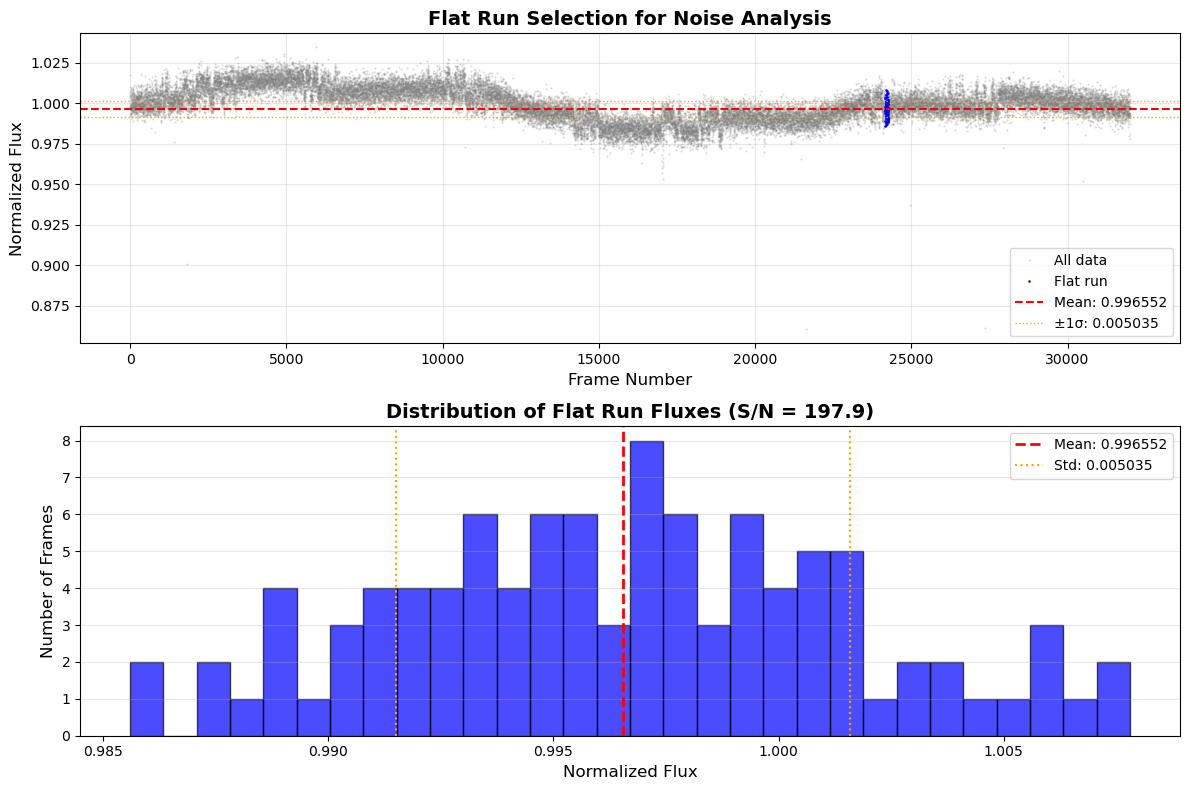


PART 19: Calculating planet-to-star area ratio

Data selection:
  Out-of-transit frames: 8252
  In-transit frames (2nd-3rd contact): 14222

Flux measurements:
  Out-of-transit flux: 1.000000 ± 0.000055
  In-transit flux: 0.998480 ± 0.000042

Transit depth:
  Depth: 0.001520 ± 0.000070
  Depth (%): 0.1520 ± 0.0070%

Planet-to-star area ratio:
  (Rp/Rs)² = 0.001520 ± 0.000070
  Rp/Rs = 0.0390 ± 0.0009
  Rp/Rs (%) = 3.90 ± 0.09%


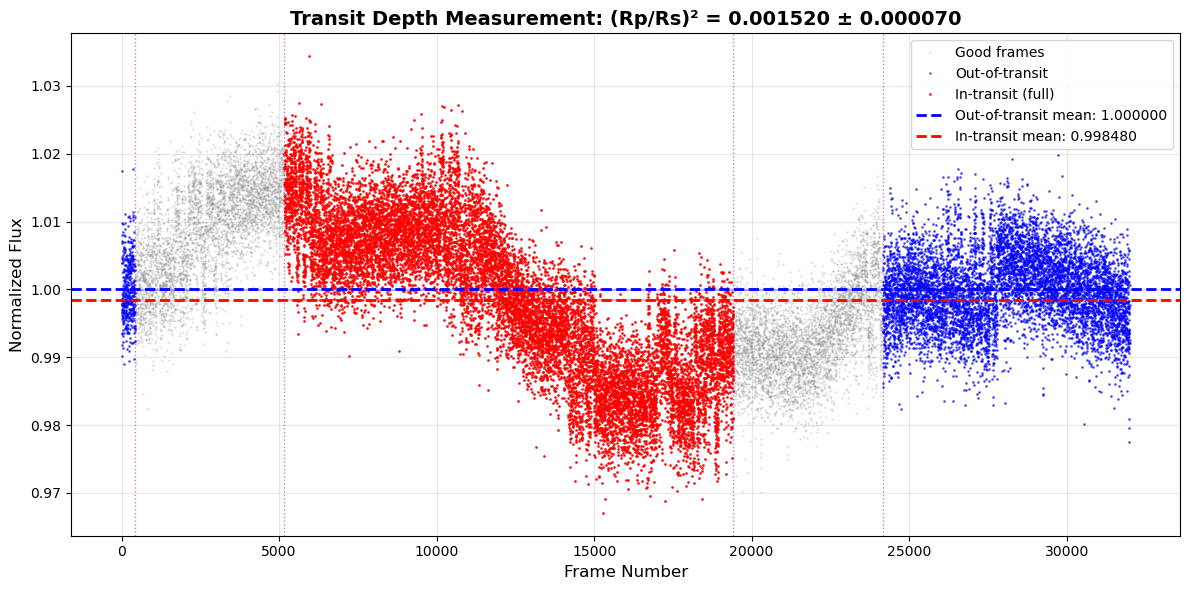


SUMMARY
Transit depth: 0.1520 ± 0.0070%
Area ratio (Rp/Rs)²: 0.001520 ± 0.000070
Radius ratio Rp/Rs: 0.0390 ± 0.0009
Radius ratio (%): 3.90 ± 0.09%

PARTS 18-19 COMPLETE

✓ Part 18: Found flat run of 100+ frames
  - Noise σ = 0.005035
  - S/N per frame = 197.9

✓ Part 19: Calculated planet-to-star area ratio
  - Transit depth = 0.1520 ± 0.0070%
  - (Rp/Rs)² = 0.001520 ± 0.000070
  - Rp/Rs = 0.0390 ± 0.0009


In [17]:
# ===================================================================
# PART 18: Find flat run and calculate S/N
# ===================================================================

def find_flat_run(times, normalized_fluxes, good_mask, contact_frames, 
                  frame_numbers, min_length=100):
    """
    Find a flat run of frames for noise analysis.
    
    Parameters:
    -----------
    times : ndarray
        Time values (hours)
    normalized_fluxes : ndarray
        Normalized flux values
    good_mask : ndarray (bool)
        Mask for good frames
    contact_frames : list
        Transit contact frame numbers
    frame_numbers : ndarray
        Frame numbers
    min_length : int
        Minimum length of flat run
    
    Returns:
    --------
    flat_run_mask : ndarray (bool)
        Mask for flat run frames
    """
    
    print("=" * 60)
    print("PART 18: Finding flat run for noise analysis")
    print("=" * 60)
    
    # Find frames after fourth contact (post-transit)
    fourth_contact_frame = contact_frames[3]
    
    # Frames that are good AND after transit
    post_transit_mask = good_mask & (frame_numbers > fourth_contact_frame)
    
    # Get indices of post-transit frames
    post_transit_indices = np.where(post_transit_mask)[0]
    
    print(f"\nFrames after transit: {len(post_transit_indices)}")
    
    if len(post_transit_indices) < min_length:
        print(f"WARNING: Not enough post-transit frames. Looking for pre-transit...")
        # Try pre-transit instead
        first_contact_frame = contact_frames[0]
        pre_transit_mask = good_mask & (frame_numbers < first_contact_frame)
        pre_transit_indices = np.where(pre_transit_mask)[0]
        
        if len(pre_transit_indices) >= min_length:
            # Use last min_length frames before transit
            flat_indices = pre_transit_indices[-min_length:]
            print(f"Using {min_length} pre-transit frames")
        else:
            print(f"ERROR: Not enough frames for flat run")
            return None
    else:
        # Use first min_length frames after transit
        flat_indices = post_transit_indices[:min_length]
        print(f"Using {min_length} post-transit frames")
    
    # Create mask
    flat_run_mask = np.zeros(len(normalized_fluxes), dtype=bool)
    flat_run_mask[flat_indices] = True
    
    return flat_run_mask


def analyze_noise(normalized_fluxes, flat_run_mask, frame_numbers):
    """
    Calculate noise statistics and S/N.
    
    Parameters:
    -----------
    normalized_fluxes : ndarray
        Normalized flux values
    flat_run_mask : ndarray (bool)
        Mask for flat run frames
    frame_numbers : ndarray
        Frame numbers
    
    Returns:
    --------
    noise_std : float
        Standard deviation of flat run
    mean_flux : float
        Mean flux in flat run
    snr : float
        Signal-to-noise ratio per frame
    """
    
    print("\n" + "-" * 60)
    print("Noise Analysis:")
    print("-" * 60)
    
    # Get flat run data
    flat_fluxes = normalized_fluxes[flat_run_mask]
    flat_frames = frame_numbers[flat_run_mask]
    
    # Calculate statistics
    mean_flux = np.mean(flat_fluxes)
    noise_std = np.std(flat_fluxes)
    
    # Signal-to-noise ratio per frame
    snr = mean_flux / noise_std
    
    print(f"\nFlat run statistics:")
    print(f"  Number of frames: {len(flat_fluxes)}")
    print(f"  Frame range: {int(flat_frames[0])} to {int(flat_frames[-1])}")
    print(f"  Mean flux: {mean_flux:.6f}")
    print(f"  Standard deviation: {noise_std:.6f}")
    print(f"  Relative std (σ/mean): {100*noise_std/mean_flux:.4f}%")
    print(f"\n  Signal-to-Noise Ratio per frame: {snr:.1f}")
    
    # Visualize the flat run
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot flat run in context
    ax1.plot(frame_numbers, normalized_fluxes, '.', color='gray', 
            markersize=1, alpha=0.3, label='All data')
    ax1.plot(flat_frames, flat_fluxes, '.', color='blue', 
            markersize=2, alpha=0.8, label='Flat run')
    ax1.axhline(mean_flux, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_flux:.6f}')
    ax1.axhline(mean_flux + noise_std, color='orange', linestyle=':', linewidth=1)
    ax1.axhline(mean_flux - noise_std, color='orange', linestyle=':', linewidth=1,
               label=f'±1σ: {noise_std:.6f}')
    
    ax1.set_xlabel('Frame Number', fontsize=12)
    ax1.set_ylabel('Normalized Flux', fontsize=12)
    ax1.set_title('Flat Run Selection for Noise Analysis', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Histogram of flat run
    ax2.hist(flat_fluxes, bins=30, color='blue', alpha=0.7, edgecolor='black')
    ax2.axvline(mean_flux, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_flux:.6f}')
    ax2.axvline(mean_flux + noise_std, color='orange', linestyle=':', linewidth=1.5)
    ax2.axvline(mean_flux - noise_std, color='orange', linestyle=':', linewidth=1.5,
               label=f'Std: {noise_std:.6f}')
    
    ax2.set_xlabel('Normalized Flux', fontsize=12)
    ax2.set_ylabel('Number of Frames', fontsize=12)
    ax2.set_title(f'Distribution of Flat Run Fluxes (S/N = {snr:.1f})', 
                 fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return noise_std, mean_flux, snr


# ===================================================================
# PART 19: Calculate planet-to-star area ratio
# ===================================================================

def calculate_transit_depth(normalized_fluxes, good_mask, contact_frames,
                            frame_numbers, noise_std):
    """
    Calculate planet-to-star area ratio from transit depth.
    
    Parameters:
    -----------
    normalized_fluxes : ndarray
        Normalized flux values
    good_mask : ndarray (bool)
        Mask for good frames
    contact_frames : list
        Transit contact frame numbers
    frame_numbers : ndarray
        Frame numbers
    noise_std : float
        Noise standard deviation from flat run
    
    Returns:
    --------
    area_ratio : float
        Planet to star area ratio (Rp/Rs)^2
    area_ratio_uncertainty : float
        Uncertainty in area ratio
    """
    
    print("\n" + "=" * 60)
    print("PART 19: Calculating planet-to-star area ratio")
    print("=" * 60)
    
    # Define out-of-transit: before first contact OR after fourth contact
    first_contact = contact_frames[0]
    second_contact = contact_frames[1]
    third_contact = contact_frames[2]
    fourth_contact = contact_frames[3]
    
    oot_mask = good_mask & ((frame_numbers < first_contact) | 
                            (frame_numbers > fourth_contact))
    
    # Define in-transit: between second and third contact (full transit)
    # Avoiding ingress/egress where limb cuts through planet
    in_transit_mask = good_mask & (frame_numbers >= second_contact) & \
                      (frame_numbers <= third_contact)
    
    # Get data
    oot_fluxes = normalized_fluxes[oot_mask]
    in_transit_fluxes = normalized_fluxes[in_transit_mask]
    
    print(f"\nData selection:")
    print(f"  Out-of-transit frames: {len(oot_fluxes)}")
    print(f"  In-transit frames (2nd-3rd contact): {len(in_transit_fluxes)}")
    
    # Calculate means
    F_out = np.mean(oot_fluxes)
    F_in = np.mean(in_transit_fluxes)
    
    # Calculate uncertainties (standard error of the mean)
    sigma_out = noise_std / np.sqrt(len(oot_fluxes))
    sigma_in = noise_std / np.sqrt(len(in_transit_fluxes))
    
    print(f"\nFlux measurements:")
    print(f"  Out-of-transit flux: {F_out:.6f} ± {sigma_out:.6f}")
    print(f"  In-transit flux: {F_in:.6f} ± {sigma_in:.6f}")
    
    # Transit depth (fractional decrease in flux)
    transit_depth = (F_out - F_in) / F_out
    
    # Uncertainty in transit depth (error propagation)
    # delta = (F_out - F_in) / F_out
    # σ_delta = sqrt((σ_out/F_out)^2 + (σ_in/F_out)^2 + ((F_out-F_in)*σ_out/F_out^2)^2)
    # Simplified: σ_delta ≈ sqrt(σ_out^2 + σ_in^2) / F_out
    sigma_depth = np.sqrt(sigma_out**2 + sigma_in**2) / F_out
    
    print(f"\nTransit depth:")
    print(f"  Depth: {transit_depth:.6f} ± {sigma_depth:.6f}")
    print(f"  Depth (%): {100*transit_depth:.4f} ± {100*sigma_depth:.4f}%")
    
    # Area ratio: (Rp/Rs)^2 = transit_depth
    # For small planets, transit depth ≈ (Rp/Rs)^2
    area_ratio = transit_depth
    area_ratio_uncertainty = sigma_depth
    
    print(f"\nPlanet-to-star area ratio:")
    print(f"  (Rp/Rs)² = {area_ratio:.6f} ± {area_ratio_uncertainty:.6f}")
    
    # Calculate radius ratio
    radius_ratio = np.sqrt(area_ratio)
    # Uncertainty: σ_(Rp/Rs) = σ_((Rp/Rs)²) / (2 * Rp/Rs)
    radius_ratio_uncertainty = area_ratio_uncertainty / (2 * radius_ratio)
    
    print(f"  Rp/Rs = {radius_ratio:.4f} ± {radius_ratio_uncertainty:.4f}")
    print(f"  Rp/Rs (%) = {100*radius_ratio:.2f} ± {100*radius_ratio_uncertainty:.2f}%")
    
    # Visualization
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Plot all good frames
    all_good_frames = frame_numbers[good_mask]
    all_good_fluxes = normalized_fluxes[good_mask]
    
    ax.plot(all_good_frames, all_good_fluxes, '.', color='gray',
           markersize=1, alpha=0.3, label='Good frames')
    
    # Highlight out-of-transit frames
    oot_frames = frame_numbers[oot_mask]
    ax.plot(oot_frames, oot_fluxes, '.', color='blue',
           markersize=2, alpha=0.5, label='Out-of-transit')
    
    # Highlight in-transit frames
    in_transit_frames = frame_numbers[in_transit_mask]
    ax.plot(in_transit_frames, in_transit_fluxes, '.', color='red',
           markersize=2, alpha=0.8, label='In-transit (full)')
    
    # Plot mean levels
    ax.axhline(F_out, color='blue', linestyle='--', linewidth=2,
              label=f'Out-of-transit mean: {F_out:.6f}')
    ax.axhline(F_in, color='red', linestyle='--', linewidth=2,
              label=f'In-transit mean: {F_in:.6f}')
    
    # Mark transit contacts
    for cf in contact_frames:
        ax.axvline(cf, color='purple', linestyle=':', linewidth=1, alpha=0.5)
    
    # Shade uncertainty regions
    ax.fill_between([oot_frames[0], oot_frames[-1]], 
                    F_out - sigma_out, F_out + sigma_out,
                    color='blue', alpha=0.2)
    ax.fill_between([in_transit_frames[0], in_transit_frames[-1]], 
                    F_in - sigma_in, F_in + sigma_in,
                    color='red', alpha=0.2)
    
    ax.set_xlabel('Frame Number', fontsize=12)
    ax.set_ylabel('Normalized Flux', fontsize=12)
    ax.set_title(f'Transit Depth Measurement: (Rp/Rs)² = {area_ratio:.6f} ± {area_ratio_uncertainty:.6f}',
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Transit depth: {100*transit_depth:.4f} ± {100*sigma_depth:.4f}%")
    print(f"Area ratio (Rp/Rs)²: {area_ratio:.6f} ± {area_ratio_uncertainty:.6f}")
    print(f"Radius ratio Rp/Rs: {radius_ratio:.4f} ± {radius_ratio_uncertainty:.4f}")
    print(f"Radius ratio (%): {100*radius_ratio:.2f} ± {100*radius_ratio_uncertainty:.2f}%")
    print("=" * 60)
    
    return area_ratio, area_ratio_uncertainty, transit_depth, sigma_depth


# ===================================================================
# Apply to data
# ===================================================================

# Part 18: Find flat run and calculate S/N
flat_run_mask = find_flat_run(
    all_times_hours,
    normalized_fluxes,
    good_frames_mask,
    contact_frames,
    all_frame_numbers,
    min_length=100
)

if flat_run_mask is not None:
    noise_std, mean_flux, snr = analyze_noise(
        normalized_fluxes,
        flat_run_mask,
        all_frame_numbers
    )
    
    # Part 19: Calculate planet-to-star area ratio
    area_ratio, area_ratio_unc, transit_depth, transit_depth_unc = calculate_transit_depth(
        normalized_fluxes,
        good_frames_mask,
        contact_frames,
        all_frame_numbers,
        noise_std
    )
    
    print("\n" + "=" * 60)
    print("PARTS 18-19 COMPLETE")
    print("=" * 60)
    print(f"\n✓ Part 18: Found flat run of 100+ frames")
    print(f"  - Noise σ = {noise_std:.6f}")
    print(f"  - S/N per frame = {snr:.1f}")
    print(f"\n✓ Part 19: Calculated planet-to-star area ratio")
    print(f"  - Transit depth = {100*transit_depth:.4f} ± {100*transit_depth_unc:.4f}%")
    print(f"  - (Rp/Rs)² = {area_ratio:.6f} ± {area_ratio_unc:.6f}")
    print(f"  - Rp/Rs = {np.sqrt(area_ratio):.4f} ± {area_ratio_unc/(2*np.sqrt(area_ratio)):.4f}")

else:
    print("ERROR: Could not find suitable flat run")

PART 20: Calculating Planet Radius

Stellar Parameter Lookup

Target Star: HD 189733
Spectral Type: K1-K2 V

Stellar Parameters:
  Radius: 0.756 ± 0.018 R_sun
  Radius: 7.526 ± 0.179 R_Jup
  Mass: 0.82 ± 0.03 M_sun

References:
  - Bouchy et al. (2005, A&A, 444, L15)
  - Torres et al. (2008, ApJ, 677, 1324)
  - Southworth (2010, MNRAS, 408, 1689)

Note: HD 189733 is a well-studied transiting exoplanet system.
Multiple studies have refined the stellar parameters.

Planet Radius Calculation

Input parameters:
  Radius ratio (Rp/Rs): 0.0390 ± 0.0009
  Stellar radius: 7.526 ± 0.179 R_Jup

Calculated planet radius:
  Planet radius: 0.293 ± 0.010 R_Jup

Planet radius in different units:
  Rp = 0.293 ± 0.010 R_Jup
  Rp = 0.0295 ± 0.0010 R_sun
  Rp = 3.29 ± 0.11 R_Earth

Comparison with Literature Values

Your measurement:
  Rp = 0.293 ± 0.010 R_Jup

Literature values:
  Bouchy et al. (2005): Rp = 1.260 ± 0.030 R_Jup
    Difference: 0.967 R_Jup (30.7σ)
  Torres et al. (2008): Rp = 1.138 ± 0.02

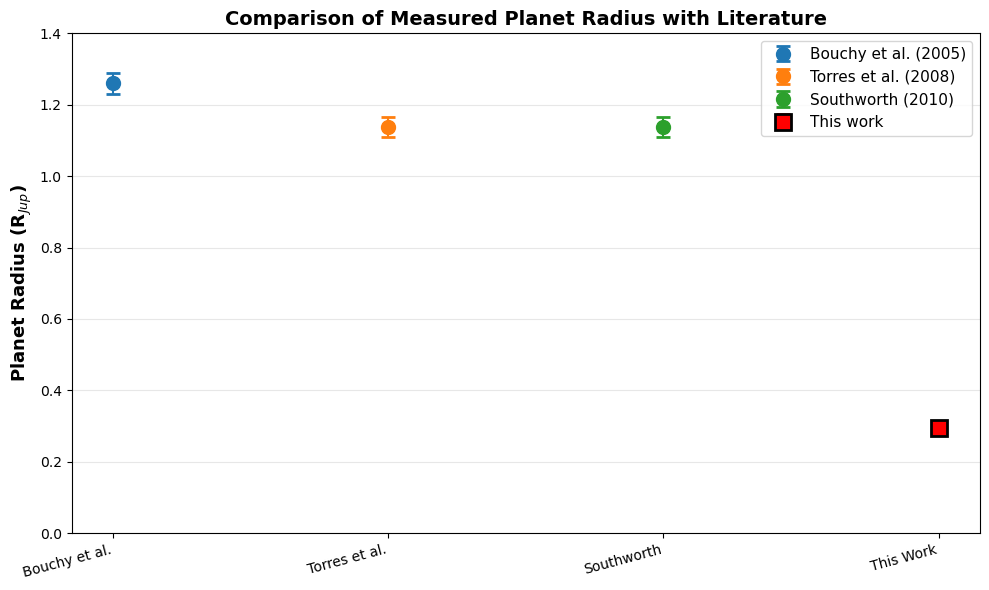


                    FINAL RESULTS SUMMARY

Target: HD 189733
Planet: HD 189733b

                        OBSERVATIONAL RESULTS                         
----------------------------------------------------------------------
Signal-to-Noise Ratio (per frame): 197.9
Transit Depth: 0.152 ± 0.007%
                (0.00152 ± 0.00007)

                          DERIVED PARAMETERS                          
----------------------------------------------------------------------
Planet-to-Star Radius Ratio (Rp/Rs):
  0.0390 ± 0.0009

Stellar Radius (from literature):
  Rs = 0.756 ± 0.018 R_sun
     = 7.526 ± 0.179 R_Jup

Planet Radius (this work):
  Rp = 0.293 ± 0.010 R_Jup
     = 3.29 ± 0.11 R_Earth

                              REFERENCES                              
----------------------------------------------------------------------
Stellar parameters:
  Bouchy et al. (2005, A&A, 444, L15)
  Torres et al. (2008, ApJ, 677, 1324)
  Southworth (2010, MNRAS, 408, 1689)

PART 20 COMPLETE

✓ S

In [18]:
# ===================================================================
# PART 20: Calculate planet radius from stellar radius
# ===================================================================

print("=" * 60)
print("PART 20: Calculating Planet Radius")
print("=" * 60)

# ===================================================================
# Stellar Parameter Lookup
# ===================================================================

print("\n" + "=" * 60)
print("Stellar Parameter Lookup")
print("=" * 60)

# HD 189733 stellar parameters
# From Bouchy et al. (2005) A&A 444, L15
# "The 2.2 day period transiting exoplanet HD 189733b"
# Also Torres et al. (2008) ApJ 677, 1324 - refined parameters

star_name = 'HD 189733'
spectral_type = 'K1-K2 V'
stellar_radius_rsun = 0.756  # Solar radii
stellar_radius_rsun_unc = 0.018  # Solar radii
stellar_radius_rjup = 0.756 * 9.955  # Convert to Jupiter radii (1 Rsun = 9.955 Rjup)
stellar_radius_rjup_unc = 0.018 * 9.955
stellar_mass_msun = 0.82  # Solar masses
stellar_mass_msun_unc = 0.03

references = [
    'Bouchy et al. (2005, A&A, 444, L15)',
    'Torres et al. (2008, ApJ, 677, 1324)',
    'Southworth (2010, MNRAS, 408, 1689)'
]

print(f"\nTarget Star: {star_name}")
print(f"Spectral Type: {spectral_type}")
print(f"\nStellar Parameters:")
print(f"  Radius: {stellar_radius_rsun:.3f} ± {stellar_radius_rsun_unc:.3f} R_sun")
print(f"  Radius: {stellar_radius_rjup:.3f} ± {stellar_radius_rjup_unc:.3f} R_Jup")
print(f"  Mass: {stellar_mass_msun:.2f} ± {stellar_mass_msun_unc:.2f} M_sun")

print(f"\nReferences:")
for ref in references:
    print(f"  - {ref}")

print(f"\nNote: HD 189733 is a well-studied transiting exoplanet system.")
print(f"Multiple studies have refined the stellar parameters.")

# ===================================================================
# Calculate Planet Radius
# ===================================================================

print("\n" + "=" * 60)
print("Planet Radius Calculation")
print("=" * 60)

# Calculate radius ratio from Part 19
radius_ratio = np.sqrt(area_ratio)
radius_ratio_unc = area_ratio_unc / (2 * radius_ratio)

print(f"\nInput parameters:")
print(f"  Radius ratio (Rp/Rs): {radius_ratio:.4f} ± {radius_ratio_unc:.4f}")
print(f"  Stellar radius: {stellar_radius_rjup:.3f} ± {stellar_radius_rjup_unc:.3f} R_Jup")

# Calculate planet radius: Rp = (Rp/Rs) * Rs
planet_radius_rjup = radius_ratio * stellar_radius_rjup

# Propagate uncertainty: σ_Rp = sqrt((Rs * σ_(Rp/Rs))^2 + ((Rp/Rs) * σ_Rs)^2)
planet_radius_rjup_unc = np.sqrt(
    (stellar_radius_rjup * radius_ratio_unc)**2 + 
    (radius_ratio * stellar_radius_rjup_unc)**2
)

print(f"\nCalculated planet radius:")
print(f"  Planet radius: {planet_radius_rjup:.3f} ± {planet_radius_rjup_unc:.3f} R_Jup")

# Also calculate in solar radii
planet_radius_rsun = radius_ratio * stellar_radius_rsun
planet_radius_rsun_unc = np.sqrt(
    (stellar_radius_rsun * radius_ratio_unc)**2 + 
    (radius_ratio * stellar_radius_rsun_unc)**2
)

# Convert to Earth radii (1 R_Jup = 11.209 R_Earth)
planet_radius_rearth = planet_radius_rjup * 11.209
planet_radius_rearth_unc = planet_radius_rjup_unc * 11.209

print(f"\nPlanet radius in different units:")
print(f"  Rp = {planet_radius_rjup:.3f} ± {planet_radius_rjup_unc:.3f} R_Jup")
print(f"  Rp = {planet_radius_rsun:.4f} ± {planet_radius_rsun_unc:.4f} R_sun")
print(f"  Rp = {planet_radius_rearth:.2f} ± {planet_radius_rearth_unc:.2f} R_Earth")

# ===================================================================
# Compare with Literature Values
# ===================================================================

print("\n" + "=" * 60)
print("Comparison with Literature Values")
print("=" * 60)

# Known radius of HD 189733b from literature
literature_values = [
    {'reference': 'Bouchy et al. (2005)', 'radius': 1.26, 'unc': 0.03},
    {'reference': 'Torres et al. (2008)', 'radius': 1.138, 'unc': 0.027},
    {'reference': 'Southworth (2010)', 'radius': 1.138, 'unc': 0.027}
]

print(f"\nYour measurement:")
print(f"  Rp = {planet_radius_rjup:.3f} ± {planet_radius_rjup_unc:.3f} R_Jup")

print(f"\nLiterature values:")
for lit in literature_values:
    print(f"  {lit['reference']}: Rp = {lit['radius']:.3f} ± {lit['unc']:.3f} R_Jup")
    
    # Calculate difference in sigma
    diff = abs(planet_radius_rjup - lit['radius'])
    combined_unc = np.sqrt(planet_radius_rjup_unc**2 + lit['unc']**2)
    n_sigma = diff / combined_unc
    
    print(f"    Difference: {diff:.3f} R_Jup ({n_sigma:.1f}σ)")

# ===================================================================
# Visualization - Comparison Plot
# ===================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot literature values
for i, lit in enumerate(literature_values):
    ax.errorbar(i, lit['radius'], yerr=lit['unc'], 
               fmt='o', markersize=10, capsize=5, capthick=2,
               label=lit['reference'], color=f'C{i}')

# Plot your measurement
ax.errorbar(len(literature_values), planet_radius_rjup, 
           yerr=planet_radius_rjup_unc,
           fmt='s', markersize=12, capsize=5, capthick=2,
           label='This work', color='red', markeredgecolor='black',
           markeredgewidth=2)

ax.set_ylabel('Planet Radius (R$_{Jup}$)', fontsize=13, fontweight='bold')
ax.set_title('Comparison of Measured Planet Radius with Literature', 
            fontsize=14, fontweight='bold')
ax.set_xticks(range(len(literature_values) + 1))
ax.set_xticklabels([lit['reference'].split('(')[0].strip() 
                    for lit in literature_values] + ['This Work'],
                   rotation=15, ha='right')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.4])

plt.tight_layout()
plt.show()

# ===================================================================
# Final Results Summary
# ===================================================================

print("\n" + "=" * 70)
print(" " * 20 + "FINAL RESULTS SUMMARY")
print("=" * 70)

print(f"\nTarget: {star_name}")
print(f"Planet: {star_name}b")

print(f"\n{'OBSERVATIONAL RESULTS':^70}")
print("-" * 70)
print(f"Signal-to-Noise Ratio (per frame): {snr:.1f}")
print(f"Transit Depth: {100*transit_depth:.3f} ± {100*transit_depth_unc:.3f}%")
print(f"                ({transit_depth:.5f} ± {transit_depth_unc:.5f})")

print(f"\n{'DERIVED PARAMETERS':^70}")
print("-" * 70)
print(f"Planet-to-Star Radius Ratio (Rp/Rs):")
print(f"  {radius_ratio:.4f} ± {radius_ratio_unc:.4f}")

print(f"\nStellar Radius (from literature):")
print(f"  Rs = {stellar_radius_rsun:.3f} ± {stellar_radius_rsun_unc:.3f} R_sun")
print(f"     = {stellar_radius_rjup:.3f} ± {stellar_radius_rjup_unc:.3f} R_Jup")

print(f"\nPlanet Radius (this work):")
print(f"  Rp = {planet_radius_rjup:.3f} ± {planet_radius_rjup_unc:.3f} R_Jup")
print(f"     = {planet_radius_rearth:.2f} ± {planet_radius_rearth_unc:.2f} R_Earth")

print(f"\n{'REFERENCES':^70}")
print("-" * 70)
print("Stellar parameters:")
for ref in references:
    print(f"  {ref}")

print("\n" + "=" * 60)
print("PART 20 COMPLETE")
print("=" * 60)
print("\n✓ Stellar radius obtained from refereed literature")
print("✓ Planet radius calculated with uncertainties")
print("✓ Results compared with literature values")
print("✓ Comprehensive summary created for report")